#**1. Load Data**

In [3]:
#Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
#Dimension Tables
df_customer=pd.read_csv('/content/drive/MyDrive/Data for Python Maz/movie_ticket_data/movie_ticket_data/customer.csv')
df_campaign=pd.read_csv('/content/drive/MyDrive/Data for Python Maz/movie_ticket_data/movie_ticket_data/campaign.csv')
df_device=pd.read_csv('/content/drive/MyDrive/Data for Python Maz/movie_ticket_data/movie_ticket_data/device_detail.csv')
df_status=pd.read_csv('/content/drive/MyDrive/Data for Python Maz/movie_ticket_data/movie_ticket_data/status_detail.csv')
#Fact Table
df_ticket=pd.read_csv('/content/drive/MyDrive/Data for Python Maz/movie_ticket_data/movie_ticket_data/ticket_history.csv')

# **2. Data Cleaning**

## **2.1 Check Data Type, value NULL & Duplicates**



#### Table: df_customer

In [5]:
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131400 entries, 0 to 131399
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   customer_id  131400 non-null  int64 
 1   usergender   131400 non-null  object
 2   dob          131400 non-null  object
dtypes: int64(1), object(2)
memory usage: 3.0+ MB


Notes:
- 131.400 rows & 3 collumns
- No NULL values in any of the columns
- Data type check → The dob column has an incorrect type → Convert from object to datetime

In [6]:
df_customer['dob']=pd.to_datetime(df_customer['dob'])
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131400 entries, 0 to 131399
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   customer_id  131400 non-null  int64         
 1   usergender   131400 non-null  object        
 2   dob          131400 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 3.0+ MB


#### Table: df_device

In [7]:
df_device.head(2)

,device_number,model,platform
0,00006afbe30ae7018c92bb324cd58afc,browser,website
1,0000b0ce524ef4d66c7bfdad67a91970,devicemodel,mobile


In [8]:
df_device.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139902 entries, 0 to 139901
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   device_number  139901 non-null  object
 1   model          132763 non-null  object
 2   platform       139902 non-null  object
dtypes: object(3)
memory usage: 3.2+ MB


Notes:
- 139.902 cols & 3 rows
- The datatype of all columns are appropriate
- The 'device_number' and 'model' cols contain NULL values -> Check the NULL ratio in these cols (If the ratio is very small- they can be removed; otherwise, replace with another words like 'unknow' or 'undefined')


In [9]:
#Create function to cal the NULL ratio
def calc_null_rate(df):
  newdf=df.isnull().sum().to_frame('null_count')
  newdf[['null_rate']]=newdf[['null_count']]/len(df)
  return newdf.sort_values(by=['null_rate'],ascending=False)

In [10]:
calc_null_rate(df_device)

,null_count,null_rate
model,7139,0.051029
device_number,1,0.000007
platform,0,0.000000


Notes:
+ The NULL ratio in 'device_number' is very low (0.000007) -> Remove rows where 'device_number' is NULL
+ The NULL ratio in 'model' is not too low or too high (0.051029) -> Replace to "unknow"


In [11]:
df_device = df_device.fillna({'model':'unknown'})
df_device = df_device[df_device['device_number'].notna()]

#### Table: Status

Notes: Transactions with a successful status (Order successful) have status_id = 1

In [12]:
df_status.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   status_id    8 non-null      int64 
 1   description  8 non-null      object
 2   error_group  7 non-null      object
dtypes: int64(1), object(2)
memory usage: 324.0+ bytes


Notes:
- The 'error_group' col has 1 NULL value (as successful transactions have no errors)
- Replace the NULL value in this column with 'unknown'

#### Table: Campaign

In [13]:
df_campaign.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   campaign_id    216 non-null    int64 
 1   campaign_type  216 non-null    object
dtypes: int64(1), object(1)
memory usage: 3.5+ KB


In [14]:
df_campaign['campaign_type'].unique()

array(['direct discount', 'voucher', 'reward point'], dtype=object)

#### Table: Ticket

In [16]:
df_ticket.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154827 entries, 0 to 154826
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   ticket_id       154827 non-null  object 
 1   customer_id     154827 non-null  int64  
 2   paying_method   154827 non-null  object 
 3   theater_name    154827 non-null  float64
 4   device_number   154827 non-null  object 
 5   original_price  154827 non-null  float64
 6   discount_value  154827 non-null  float64
 7   final_price     154827 non-null  float64
 8   time            154827 non-null  object 
 9   status_id       154827 non-null  int64  
 10  campaign_id     154827 non-null  int64  
 11  movie_name      154827 non-null  object 
dtypes: float64(4), int64(3), object(5)
memory usage: 14.2+ MB


In [17]:
#Convert the datatype of 'time' col
df_ticket['time']=pd.to_datetime(df_ticket['time'])

In [18]:
#Remove duplicated values
df_ticket.drop_duplicates(inplace=True)

## **2.2 Join Tables**

In [19]:
df_join_customer=pd.merge(df_ticket,df_customer,how='left',on='customer_id')

In [20]:
df_join_status=pd.merge(df_join_customer,df_status,how='left',on='status_id')

In [21]:
df_join_campaign=pd.merge(df_join_status,df_campaign,how='left',on='campaign_id')

In [22]:
df_join_all=pd.merge(df_join_campaign,df_device,how='left', on='device_number')

In [23]:
df_join_all.head(2)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,usergender,dob,description,error_group,campaign_type,model,platform
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,Male,1989-02-25,Order successful,NaN,direct discount,"iPhone13,1",mobile
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,Male,1991-06-09,Order successful,NaN,direct discount,browser,website


In [24]:
df_join_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154725 entries, 0 to 154724
Data columns (total 19 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   ticket_id       154725 non-null  object        
 1   customer_id     154725 non-null  int64         
 2   paying_method   154725 non-null  object        
 3   theater_name    154725 non-null  float64       
 4   device_number   154725 non-null  object        
 5   original_price  154725 non-null  float64       
 6   discount_value  154725 non-null  float64       
 7   final_price     154725 non-null  float64       
 8   time            154725 non-null  datetime64[ns]
 9   status_id       154725 non-null  int64         
 10  campaign_id     154725 non-null  int64         
 11  movie_name      154725 non-null  object        
 12  usergender      154725 non-null  object        
 13  dob             154725 non-null  datetime64[ns]
 14  description     154725 non-null  obj

In [25]:
#Check the NULL ratio in the table
calc_null_rate(df_join_all)

,null_count,null_rate
error_group,133679,0.863978
campaign_type,63098,0.407807
model,78,0.000504
platform,78,0.000504
paying_method,0,0.000000
ticket_id,0,0.000000
customer_id,0,0.000000
theater_name,0,0.000000
device_number,0,0.000000
original_price,0,0.000000


### Notes:
After joining tables, some columns still have NULLs:
- 'error_group': NULLs are expected for successful transactions → Replace with 'unknown'.
- 'campaign_type': NULLs appear only for non-promotional orders → Replace with 'unknown'.
- 'platform & model': NULLs may occur if device_id is missing → Replace with 'unknown'.

In [26]:
#Repalce NULL values
df_join_all=df_join_all.fillna({'platform':'unknown','model':'unknown','error_group':'unknown','campaign_type':'unknown'})

## **2.3 View all values of each collumns**

In [27]:
df_join_all.nunique().sort_values(ascending=False)

,0
ticket_id,154725
time,154725
device_number,126459
customer_id,119477
dob,11322
final_price,2715
original_price,1895
model,1215
movie_name,253
discount_value,242


In [28]:
# List all the values in all cols
specific_cols=['movie_name','description','paying_method','campaign_type','usergender','platform', 'error_group']
for col in specific_cols:
  print(col + ':', np.sort(df_join_all[col].unique().astype(str)))
  print('\r')
  print('--------------------------------------------------')
  print('\r')


movie_name: ['13rd Sister' '13rd Sister: Three Deadly Days' '1990' '2037'
 '30 Chua Phai Tet' '47 Meters Down: Uncaged' 'A Chamada Da Selva'
 'A Diamond In The Rough' 'Accidentally Dad' 'Aladdin' 'Alienoid'
 'Alita: Battle Angel' 'Ambulance' 'Anchor' 'Angel Has Fallen' 'Anna'
 'Annabelle Comes Home' 'Aquaman' 'Around The World In 80 Days'
 'Autumn Promise' 'Avatar' 'Avatar: The Way Of Water' 'Avengers: Endgame'
 'Bad Boys For Life' 'Batman' 'Beast' 'Birds Of Prey' 'Black Adam'
 'Black Panther 2: Wakanda Forever' 'Black Panther: Wakanda Forever'
 'Blood Karma' 'Blood Moon Party' 'Bloodshot' 'Broker' 'Bullet Train'
 'Bumblebee' 'Bắc Kim Thang' 'Camellia Sisters' 'Captain Marvel'
 "Charlie's Angels" 'Cherry Magic The Movie Thirty Years'
 'Chickenhare And The Hamster Of Darkness' 'Chuyện Ma Đô Thị' 'Collectors'
 'Concessions' 'Confidential Assignment 2: International' 'Cracked'
 'Crawl' 'Crazy Romance' "Dad I'm Sorry" 'Daddy Issues' 'Daeng'
 'Dark Figure Of Crime' 'Dc League Of Super-Pets'

# **3. Analyze**

## **3.1 Customer portrait**

### **Age and Gender Distribution**

In [29]:
#Print the current date
from datetime import datetime
current_day=datetime.now()
current_day

datetime.datetime(2025, 3, 24, 9, 16, 16, 576092)

In [30]:
#Print the age of customers
col_days = (current_day - df_join_all['dob']).dt.days
df_join_all['age']=col_days/365.25 #Tính cả năm nhuận
df_join_all['age'].astype(int)


,age
0,36
1,33
2,35
3,27
4,36
...,...
154720,24
154721,29
154722,44
154723,55


In [31]:
df_cus = df_join_all[['customer_id','usergender','age']]
df_cus['age']=df_cus['age'].astype(int)

<ipython-input-31-a2b2d35dc4e1>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cus['age']=df_cus['age'].astype(int)


In [32]:
#Remove duplicates in the col 'customer_id'
df_cus.drop_duplicates(inplace=True)

<ipython-input-32-f4ec786cd98c>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cus.drop_duplicates(inplace=True)


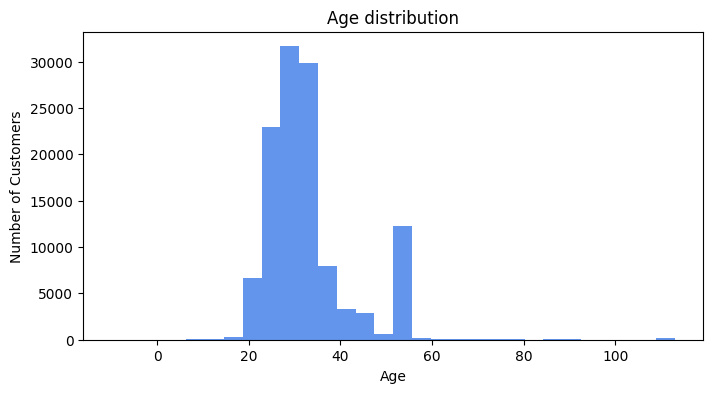

In [33]:
#View the Age Distribution
plt.figure(figsize=(8,4))
df_cus['age'].hist(bins=30,color='cornflowerblue',grid=False)

plt.title('Age distribution')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()

In [34]:
#View some popular age
df_cus_top_age = df_cus[df_cus['usergender']!='Not verify'].groupby('age').agg(total_customers=('customer_id','count')).sort_values(by='total_customers',ascending=False).reset_index()
df_cus_top_age.head(10)

,age,total_customers
0,29,8553
1,30,7859
2,28,7756
3,31,7573
4,27,7020
5,25,6914
6,32,6459
7,24,6155
8,26,5987
9,33,5960


In [35]:
df_cus_top_age = df_cus[df_cus['usergender']!='Not verify'].groupby('age').agg(total_customers=('customer_id','count')).sort_values(by='age',ascending=False).reset_index()
df_cus_top_age.head(10)

,age,total_customers
0,113,69
1,112,54
2,111,3
3,110,4
4,109,4
5,108,2
6,107,2
7,106,4
8,105,6
9,104,3


Notes:
- Most customers are aged between 25-35.
- The peak of the histogram falls within 30-35, indicating the highest number of customers in this age range.
- Some anomalies exist, such as an unusual increase in the 55-60 age group.
- There are customers over 100 years old placing orders (requires verification).

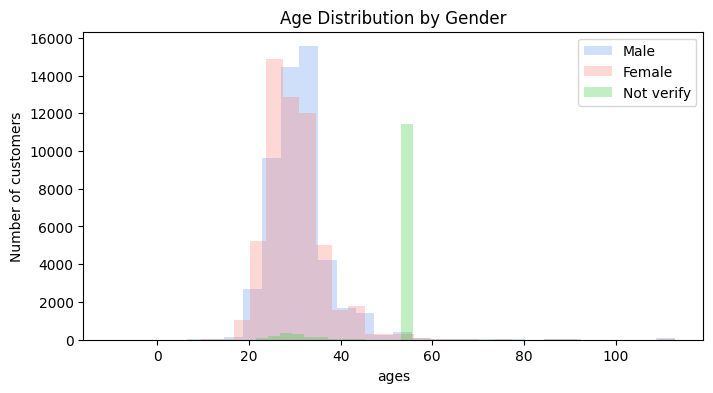

In [36]:
#Age Distribution by Gender

plt.figure(figsize=(8,4))

male_age= df_cus[df_cus['usergender']=='Male']['age']
female_age=df_cus[df_cus['usergender']=='Female']['age']
unknown_age=df_cus[df_cus['usergender']=='Not verify']['age']

plt.hist(male_age, bins=30, alpha=0.3, color='cornflowerblue', label='Male')
plt.hist(female_age, bins=30, alpha = 0.3, color = 'salmon', label = 'Female')
plt.hist(unknown_age, bins=30, alpha = 0.3, color = 'limegreen', label = 'Not verify')

plt.title('Age Distribution by Gender')
plt.xlabel('ages')
plt.ylabel('Number of customers')
plt.legend()
plt.show()


Notes: There is a coincidence where the Gender Verify group (lime green) is concentrated around the age of 55

> Question: Could it be that users in this age range have not verified their accounts (which is why their gender is unknown, while their DOB might be defaulted to 1970)?

### **Check 'Not Verify'**


In [37]:
df_gender= df_cus.groupby('usergender').agg(total_cus=('customer_id','count')).reset_index()
df_gender

,usergender,total_cus
0,Female,55689
1,Male,50873
2,Not verify,12915


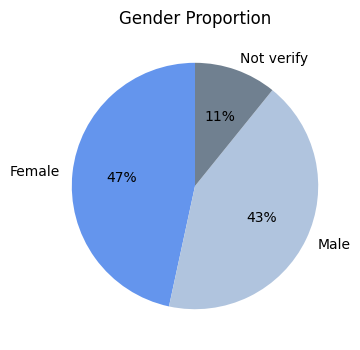

In [38]:
#The proportion of 3 genders
plt.figure(figsize=(8,4))

plt.pie(df_gender['total_cus'],
        labels=df_gender['usergender'],
        colors=['cornflowerblue','lightsteelblue','slategrey'],
        autopct='%1.0f%%',
        startangle=90)

plt.title('Gender Proportion')
plt.show()

Notes:The 'Not verify' group accounts for 11% -> 2 possible cases:
- If they manually entered their DOB, the age data is accurate
- If they did not enter it, the system might auto-fill it as 1970 (~55 years old)
(This is just a hypothesis, as many apps default to this when DOB is missing, potentially causing outliers in the age data)

> Next step: Verify this by checking the exact age distribution within the unverified group.

In [39]:
df_cus_check=df_cus[df_cus['usergender']=='Not verify'].groupby('age').agg(number=('customer_id','count')).reset_index().sort_values(by='number',ascending=False)
df_cus_check.head(5)

,age,number
39,55,11434
13,29,133
15,31,119
11,27,116
14,30,107


Notes: The increase in the "Verify" group aligns with the 55-year-old range (born in 1970)
> These customers likely didn't enter DOB (auto-filled as 1970) or manually entered 1970

### **Age generation distribution**

Notes: We can analyze the age by dividing 4 groups

In [40]:
df_cus_3 = df_join_all.drop_duplicates(subset=['customer_id'])[['customer_id','dob','usergender','age']]
df_cus_3['age']=df_cus_3['age'].astype(int)
df_cus_3.head(5)

,customer_id,dob,usergender,age
0,100009,1989-02-25,Male,36
1,100493,1991-06-09,Male,33
2,100596,1989-05-18,Male,35
3,100852,1997-08-31,Male,27
4,100965,1988-09-20,Male,36


#### **Content of Age Distribution:**
> We choose the current year is 2025
+ Baby Boomers (1946 - 1964): 61-79
+ Generation X (1965 - 1980):45- 60
+ Generation Y (Millennials) (1981 - 1996): 29-44
+ Generation Z (1997 - 2012): 16-28


Notes: In this section, although some customers are older than the Baby Boomers group, they have been included for analysis along with this generation

In [41]:
df_cus_3['age_generation'] = df_cus_3['dob'].apply(lambda x: 'Baby Bommers' if x.year < 1965
                                                     else 'Gen X' if x.year < 1981
                                                     else 'Gen Y' if x.year < 1997
                                                     else 'Gen Z' if x.year < 2013 else 'Others')
df_cus_3.head(4)

,customer_id,dob,usergender,age,age_generation
0,100009,1989-02-25,Male,36,Gen Y
1,100493,1991-06-09,Male,33,Gen Y
2,100596,1989-05-18,Male,35,Gen Y
3,100852,1997-08-31,Male,27,Gen Z


In [42]:
df_cus_4= df_cus_3[df_cus_3['usergender']!='Not verify'].groupby('age_generation').agg(total_cus = ('customer_id','count')).sort_values(by='total_cus',ascending=False).reset_index()
df_cus_4.head(5)

,age_generation,total_cus
0,Gen Y,63310
1,Gen Z,38358
2,Gen X,4261
3,Baby Bommers,590
4,Others,43


In [43]:
df_cus_4['total']=df_cus_4['total_cus'].sum()
df_cus_4

,age_generation,total_cus,total
0,Gen Y,63310,106562
1,Gen Z,38358,106562
2,Gen X,4261,106562
3,Baby Bommers,590,106562
4,Others,43,106562


In [44]:
df_cus_4['percent_gen']=((df_cus_4['total_cus']/df_cus_4['total'])*100).round(2)
df_cus_4

,age_generation,total_cus,total,percent_gen
0,Gen Y,63310,106562,59.41
1,Gen Z,38358,106562,36.00
2,Gen X,4261,106562,4.00
3,Baby Bommers,590,106562,0.55
4,Others,43,106562,0.04


In [45]:
df_others_gen = df_cus_3[df_cus_3['age_generation']=='Others'][['customer_id','dob','age']].sort_values(by='age',ascending=False)
df_others_gen.head(5)

,customer_id,dob,age
15613,155381,2013-01-20,12
3199,127245,2014-01-01,11
25521,167444,2013-06-07,11
27771,176508,2013-05-06,11
25809,167372,2013-06-06,11


#### Notes:
- 1 customer has a negative age (-10) → Verify.
- Gen Alpha (2013 to present) makes up 0.12%
> Update table (remove -10, add Alpha group)

In [46]:
df_cus_3 = df_cus_3[df_cus_3['age']>0]
df_cus_3['age_generation'] = df_cus_3['dob'].apply(lambda x: 'Baby Bommers' if x.year < 1965
                                                     else 'Gen X' if x.year < 1981
                                                     else 'Gen Y' if x.year < 1997
                                                     else 'Gen Z' if x.year < 2010
                                                     else 'Gen Alpha')
df_cus_3.head(4)

,customer_id,dob,usergender,age,age_generation
0,100009,1989-02-25,Male,36,Gen Y
1,100493,1991-06-09,Male,33,Gen Y
2,100596,1989-05-18,Male,35,Gen Y
3,100852,1997-08-31,Male,27,Gen Z


In [47]:
df_cus_4= df_cus_3[df_cus_3['usergender']!='Not verify'].groupby('age_generation').agg(total_cus = ('customer_id','count')).sort_values(by='total_cus',ascending=False).reset_index()
df_cus_4.head(5)

,age_generation,total_cus
0,Gen Y,63310
1,Gen Z,38276
2,Gen X,4261
3,Baby Bommers,590
4,Gen Alpha,124


Notes: Gen Z has the highest number of customers

#### **Combined view of 2 charts**

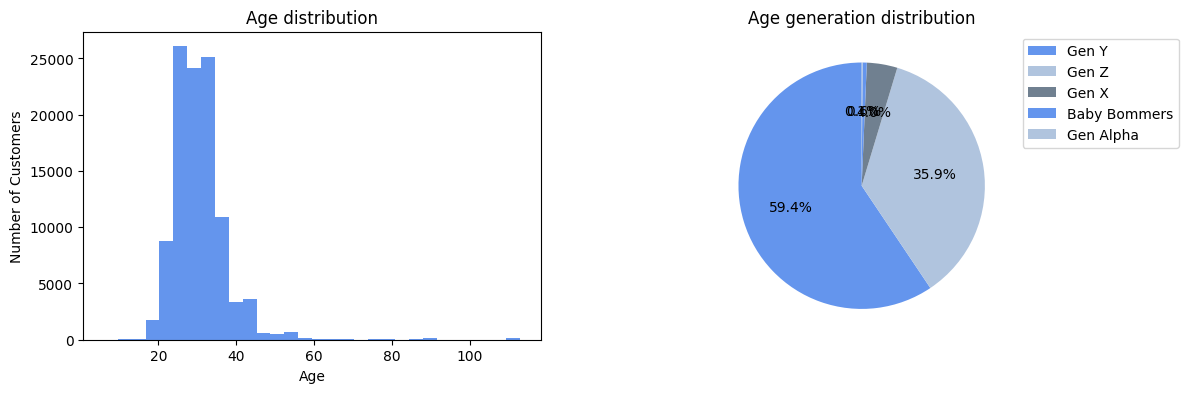

In [48]:
plt.figure(figsize=(13,4))

ax1 = plt.subplot(1,2,1)
df_cus_3[df_cus_3['usergender']!= 'Not verify']['age'].hist(bins=30,color='cornflowerblue',grid=False)
plt.title('Age distribution')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
ax2 = plt.subplot(1,2,2)
plt.pie(df_cus_4['total_cus'],
        labels=None,
        colors=['cornflowerblue','lightsteelblue','slategrey'],
        autopct='%1.1f%%',
        startangle=90,
        labeldistance=1.1)
plt.legend(df_cus_4['age_generation'],loc="upper left", bbox_to_anchor=(1, 1))
plt.title('Age generation distribution')

plt.show()

Notes: After removing the 'Not verify' user gender group, the Age distribution no longer has outliers

## **3.2 Time Series Data - When did customers buy tickets**

In [49]:
#Add some new cols related time: weekly, monthly, yearly or month-year
df_join_all['Month']=df_join_all['time'].dt.month
df_join_all['Hour']=df_join_all['time'].dt.hour
df_join_all['Day Name']=df_join_all['time'].dt.day_name()
df_join_all['year_month']=df_join_all['time'].dt.strftime('%Y-%m')


#### **The number of tickers by Month Year**

In [50]:
#Month Year
df_month_year = df_join_all.groupby('year_month').agg(no_of_tickets=('ticket_id','count')).sort_values(by='year_month').reset_index()
df_month_year.head(4)

,year_month,no_of_tickets
0,2019-01,2019
1,2019-02,1626
2,2019-03,1004
3,2019-04,4069


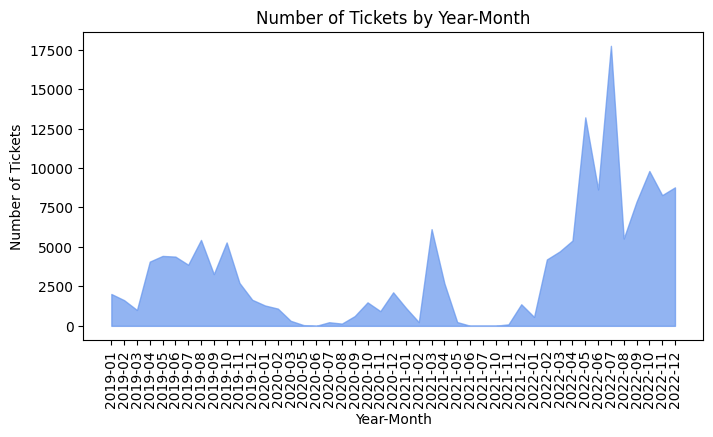

In [51]:
plt.figure(figsize=(8,4))

plt.fill_between(df_month_year['year_month'],
                 df_month_year['no_of_tickets'],
                 color='cornflowerblue',
                 alpha=0.7)

plt.title('Number of Tickets by Year-Month')
plt.xlabel('Year-Month')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=90)
plt.show()

**Notes:**
- Some time periods are missing from the display.
> Create a time dimension table and join it with the data to check if the issue is due to errors or missing data for these months (4/2020, 8/2021, 9/2021).

#### **A TIME DIMENSION TABLE**

In [52]:
start_date = '2019-01-01'
end_date = '2022-12-31'

date_range = pd.date_range(start=start_date, end=end_date,freq='MS')

list_month = date_range.month
list_month_name = date_range.strftime('%B')
list_year = date_range.year
list_year_month = date_range.strftime('%Y-%m')

dim_time = pd.DataFrame({
    'month_number': list_month,
    'month_name': list_month_name,
    'year': list_year,
    'year_month': list_year_month
})
dim_time.head(4)

,month_number,month_name,year,year_month
0,1,January,2019,2019-01
1,2,February,2019,2019-02
2,3,March,2019,2019-03
3,4,April,2019,2019-04


In [53]:
# Merge 2 tables to fill in the missing data
df_time_merge = pd.merge(dim_time,df_month_year,how='left',on='year_month')
df_time_merge.head(4)

,month_number,month_name,year,year_month,no_of_tickets
0,1,January,2019,2019-01,2019.0
1,2,February,2019,2019-02,1626.0
2,3,March,2019,2019-03,1004.0
3,4,April,2019,2019-04,4069.0


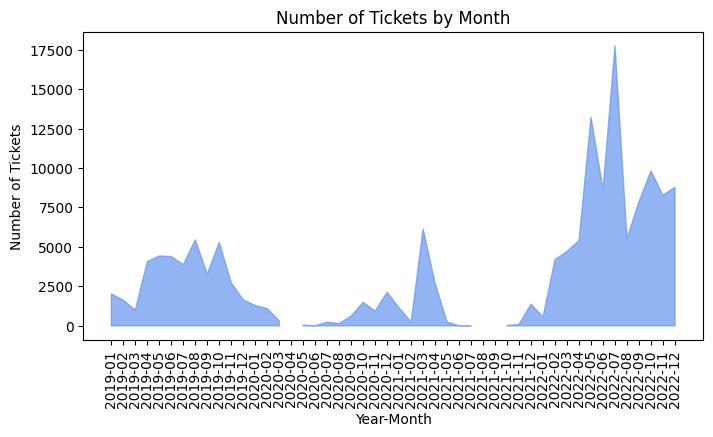

In [54]:
plt.figure(figsize=(8,4))

plt.fill_between(df_time_merge['year_month'],
                 df_time_merge['no_of_tickets'],
                 color='cornflowerblue',
                 alpha=0.7)

plt.title('Number of Tickets by Month')
plt.xlabel('Year-Month')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=90)
plt.show()

Notes: At this point, the missing values (NaN sections in the chart) are blank

#### **The number of Tickets by Day Name**

In [55]:
df_day_name = df_join_all.groupby('Day Name').agg(no_of_tickets=('ticket_id','count')).sort_values(by='Day Name').reset_index()
df_day_name

,Day Name,no_of_tickets
0,Friday,26438
1,Monday,16702
2,Saturday,34450
3,Sunday,26960
4,Thursday,19101
5,Tuesday,14793
6,Wednesday,16281


In [56]:
df_join_all['Dayofweek']=df_join_all['time'].dt.dayofweek
df_join_all.head(2)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,...,error_group,campaign_type,model,platform,age,Month,Hour,Day Name,year_month,Dayofweek
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,...,unknown,direct discount,"iPhone13,1",mobile,36.073922,7,17,Friday,2022-07,4
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,...,unknown,direct discount,browser,website,33.790554,7,20,Friday,2022-07,4


In [57]:
df_day_name_1 = df_join_all.groupby(['Dayofweek','Day Name']).agg(no_of_tickets=('ticket_id','count')).sort_values(by='Dayofweek').reset_index()
df_day_name_1.head(4)


,Dayofweek,Day Name,no_of_tickets
0,0,Monday,16702
1,1,Tuesday,14793
2,2,Wednesday,16281
3,3,Thursday,19101


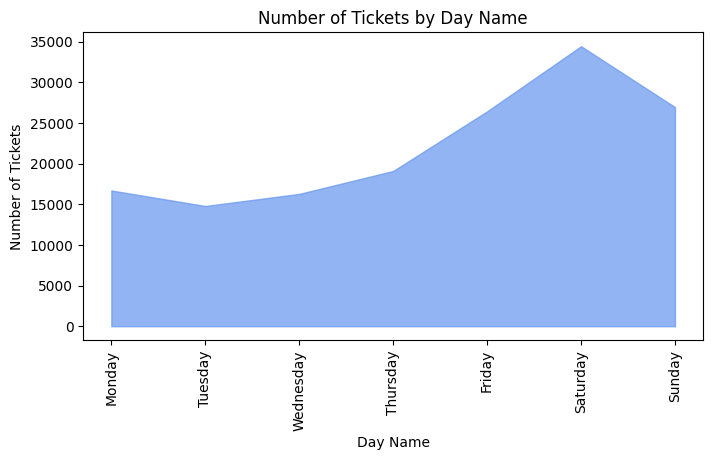

In [58]:
plt.figure(figsize=(8,4))

plt.fill_between(df_day_name_1['Day Name'],
                 df_day_name_1['no_of_tickets'],
                 color='cornflowerblue',
                 alpha=0.7)

plt.title('Number of Tickets by Day Name')
plt.xlabel('Day Name')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=90)
plt.show()

#### **The number of tickets Hour**

In [59]:
df_hour = df_join_all.groupby('Hour').agg(no_of_tickets=('ticket_id','count')).sort_values(by='Hour').reset_index()
df_hour.head(4)

,Hour,no_of_tickets
0,0,2352
1,1,964
2,2,398
3,3,159


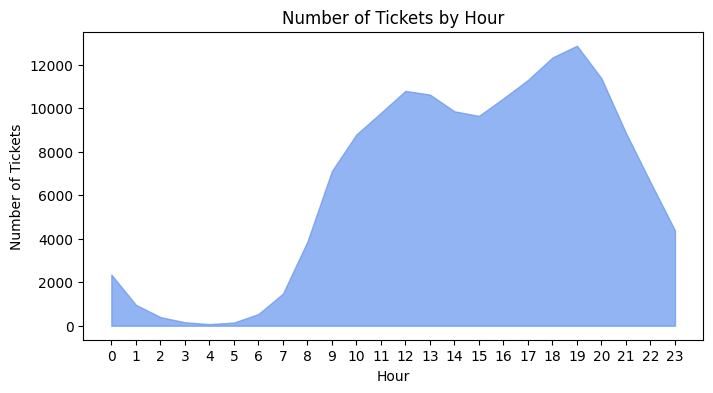

In [60]:
plt.figure(figsize=(8,4))
plt.fill_between(df_hour['Hour'],df_hour['no_of_tickets'],color='cornflowerblue',alpha=0.7)

x_values = [i for i in range(24)]

plt.title('Number of Tickets by Hour')
plt.xlabel('Hour')
plt.ylabel('Number of Tickets')
plt.xticks(x_values)
plt.show()

**Notes:**
- In the early hours (0 AM - 7 AM), ticket sales are low, ranging from 0 to 2,000
- From 7 AM - 12 PM, sales increase and then start declining after 7 PM
- Peak ticket sales occur between 11 AM - 1 PM and 6 PM - 8 PM

## **3.3 Factors Analysis**

### **Payment Platform**

In [61]:
df_platform_0 = df_join_all.groupby('platform').agg(no_of_tickets=('ticket_id','count')).reset_index()
df_platform_0

,platform,no_of_tickets
0,mobile,138136
1,unknown,78
2,website,16511


In [62]:
calc_null_rate(df_platform_0)

,null_count,null_rate
platform,0,0.0
no_of_tickets,0,0.0


Notes: 'Unknown' devices are few (78) -> they can be removed to compare payment trends between mobile and website

In [63]:
df_platform = df_join_all[df_join_all['platform'] != 'unknown'].groupby('platform').agg(no_of_tickets=('ticket_id','count')).reset_index()
df_platform

,platform,no_of_tickets
0,mobile,138136
1,website,16511


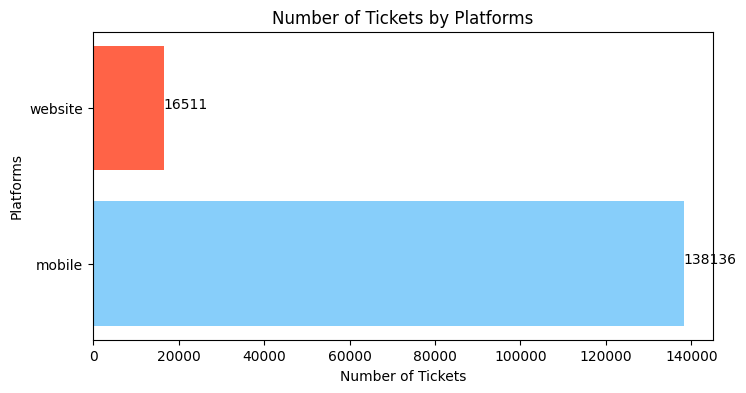

In [64]:
plt.figure(figsize=(8,4))

plt.barh(
    df_platform['platform'],
    df_platform['no_of_tickets'],
    color = df_platform['platform'].replace({'mobile':'lightskyblue','website':'tomato'})
)

plt.title('Number of Tickets by Platforms')
plt.ylabel('Platforms')
plt.xlabel('Number of Tickets')

for index, value in enumerate(df_platform['no_of_tickets']):
  plt.text(value, index, str(value))

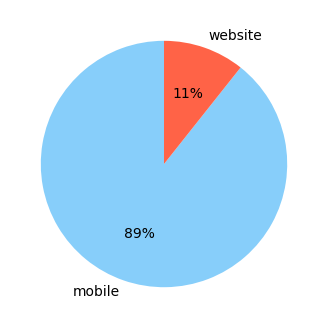

In [65]:
plt.figure(figsize=(13,4))

plt.pie(
    df_platform['no_of_tickets'],
    labels = df_platform['platform'],
    colors=df_platform['platform'].replace({'mobile':'lightskyblue','website':'tomato'}),
    autopct = '%1.0f%%',
    startangle=90
)

plt.show()

In [66]:
# Create a time-based table to analyze platform usage trends over time
df_platform_1 = df_join_all.groupby(['year_month','platform']).agg(
    no_of_tickets=('ticket_id','count')
).reset_index()
df_platform_1

,year_month,platform,no_of_tickets
0,2019-01,mobile,2019
1,2019-02,mobile,1626
2,2019-03,mobile,1004
3,2019-04,mobile,4069
4,2019-05,mobile,4430
...,...,...,...
71,2022-10,website,1849
72,2022-11,mobile,6677
73,2022-11,website,1603
74,2022-12,mobile,6959


In [67]:
df_platform_1 = df_platform_1[df_platform_1['platform'] != 'unknown']
df_platform_1

,year_month,platform,no_of_tickets
0,2019-01,mobile,2019
1,2019-02,mobile,1626
2,2019-03,mobile,1004
3,2019-04,mobile,4069
4,2019-05,mobile,4430
...,...,...,...
71,2022-10,website,1849
72,2022-11,mobile,6677
73,2022-11,website,1603
74,2022-12,mobile,6959


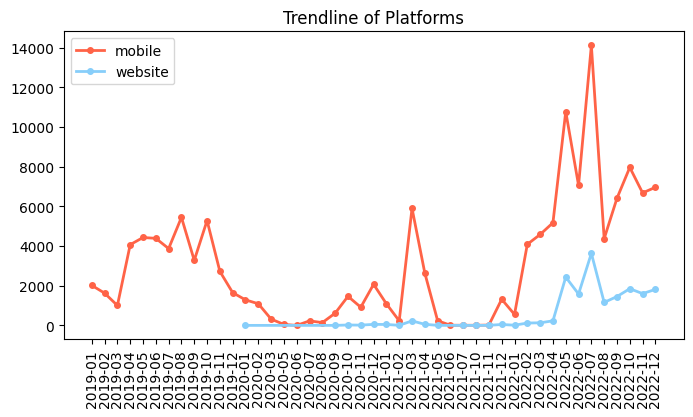

In [68]:
plt.figure(figsize=(8,4))

#Data
df_mobile_line = df_platform_1[df_platform_1['platform']=='mobile']
df_website_line = df_platform_1[df_platform_1['platform']=='website']

#Line 1:
plt.plot(df_mobile_line['year_month'],
         df_mobile_line['no_of_tickets'],
         label = 'mobile',
         marker = 'o',
         markersize = 4,
         color = 'tomato',
         linewidth = 2,
)

#Line 2:
plt.plot(df_website_line['year_month'],
         df_website_line['no_of_tickets'],
         label = 'website',
         marker = 'o',
         markersize = 4,
         color = 'lightskyblue',
         linewidth = 2,
)

plt.title('Trendline of Platforms')
plt.xticks(rotation=90)
plt.legend()

plt.show()


In [69]:
# Website start being used:
df_website_line.sort_values(by='year_month').head(5)


,year_month,platform,no_of_tickets
13,2020-01,website,2
21,2020-09,website,2
23,2020-10,website,22
25,2020-11,website,15
27,2020-12,website,53


Notes: The website started being used in January 2020, with more data appearing in September 2020

### **Operating System version**

In [70]:
df_join_all['model'].unique()

array(['iPhone13,1', 'browser', 'unknown', ..., 'Samsung SM-J727S',
       'Zuk Z1', 'Samsung SM-N9750'], dtype=object)

> Operating System version has 4 groups
+ IOS (Some model has the word 'iPhone')
+ Android others (has 'Samsung','Oppo',...)
+ Browser (browser)
+ Unknown

In [71]:
df= df_join_all.groupby('model').agg(no_of_tickets=('ticket_id','count')).sort_values(by='no_of_tickets',ascending=False).reset_index()

df

,model,no_of_tickets
0,devicemodel,61867
1,browser,13377
2,unknown,6987
3,"iPhone11,6",6119
4,"iPhone9,4",4172
...,...,...
1210,Samsung SM-G930T,1
1211,Samsung SM-G950W,1
1212,Asus ASUS_I003D,1
1213,Asus ASUS_X01AD,1


In [72]:
#Add col 'os_version'
df_join_all['os_version'] = df_join_all['model'].apply(lambda x:'ios'
                                       if ('iPhone' in x or 'iPod' in x or 'iPad' in x)
                                       else 'browser' if x=='browser'
                                       else 'unknown' if x=='unknown'
                                       else 'android & others')

df_join_all.head(4)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,...,campaign_type,model,platform,age,Month,Hour,Day Name,year_month,Dayofweek,os_version
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,...,direct discount,"iPhone13,1",mobile,36.073922,7,17,Friday,2022-07,4,ios
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,...,direct discount,browser,website,33.790554,7,20,Friday,2022-07,4,browser
2,1fdbeb7eceba8a27d9d985b5b70c219a,100596,money in app,56.0,69cf9244654949047f006e441fa7a8a7,10.31,2.31,8.00,2022-07-30 11:16:55.483,1,...,unknown,unknown,mobile,35.849418,7,11,Saturday,2022-07,5,unknown
3,7715c9955866bd296b98543412839abd,100852,bank account,119.0,879ed11af9d6d2b5cda4d299590735a7,27.75,1.03,26.72,2022-07-04 22:33:07.458,1,...,direct discount,devicemodel,mobile,27.561944,7,22,Monday,2022-07,0,android & others


In [73]:
df_model_1 = df_join_all.groupby('os_version').agg(no_of_tickets=('ticket_id','count')).reset_index()
df_model_1

,os_version,no_of_tickets
0,android & others,82801
1,browser,13377
2,ios,51560
3,unknown,6987


**100% stacked area chart**



In [74]:
df_model_4 = (
    df_join_all
    .pivot_table(index='year_month', columns='os_version', aggfunc='count',values='ticket_id')
    .reset_index()

)
df_model_4.head(4)

os_version,year_month,android & others,browser,ios,unknown
0,2019-01,704.0,NaN,1243.0,72.0
1,2019-02,537.0,NaN,1079.0,10.0
2,2019-03,366.0,NaN,636.0,2.0
3,2019-04,1504.0,NaN,2556.0,9.0


#### **Combined view of 3 charts**

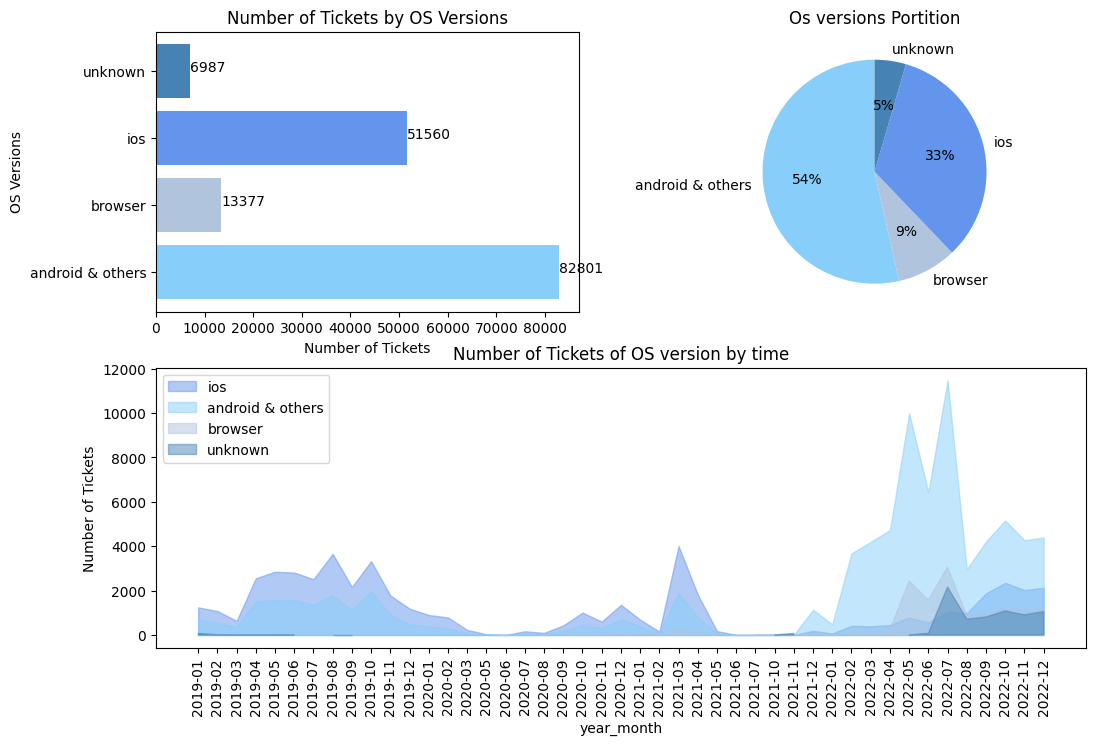

<Figure size 640x480 with 0 Axes>

In [75]:
plt.figure(figsize=(12,8))

#Plot 1
axis1 = plt.subplot(2,2,1)
plt.barh(
    df_model_1['os_version'], df_model_1['no_of_tickets'],
    color = df_model_1['os_version'].replace({'browser': 'lightsteelblue',  'android & others': 'lightskyblue', 'ios': 'cornflowerblue', 'unknown': 'steelblue'})
)

plt.title('Number of Tickets by OS Versions')
plt.ylabel('OS Versions')
plt.xlabel('Number of Tickets')

for index, value in enumerate(df_model_1['no_of_tickets']):
  plt.text(value, index, str(value))

#Plot 2
axis2 = plt.subplot(2,2,2)
plt.pie(
    df_model_1['no_of_tickets'],
    labels = df_model_1['os_version'],
    colors=df_model_1['os_version'].replace({'browser': 'lightsteelblue',  'android & others': 'lightskyblue', 'ios': 'cornflowerblue', 'unknown': 'steelblue'}),
    autopct = '%1.0f%%',
    startangle=90
)
plt.title('Os versions Portition')

#Plot 3
axis3 = plt.subplot(2,1,2)
plt.fill_between(df_model_4['year_month'], df_model_4['ios'],color='cornflowerblue',alpha=0.5, label='ios')
plt.fill_between(df_model_4['year_month'], df_model_4['android & others'],color='lightskyblue',alpha=0.5, label='android & others')
plt.fill_between(df_model_4['year_month'], df_model_4['browser'],color='lightsteelblue',alpha=0.5, label='browser')
plt.fill_between(df_model_4['year_month'], df_model_4['unknown'],color='steelblue',alpha=0.5, label='unknown')


plt.title('Number of Tickets of OS version by time')
plt.ylabel('Number of Tickets')
plt.xlabel('year_month')
plt.xticks(rotation=90)
plt.legend()
plt.show()

plt.subplots_adjust(hspace=3, top=0.8)


### **Paying Method**


In [76]:
df_payment_0 = df_join_all[df_join_all['paying_method'] != 'other']

In [77]:
df_payment_1 = df_payment_0.groupby('paying_method').agg(no_of_orders=('ticket_id','count')).sort_values(by='no_of_orders').reset_index()
df_payment_1

,paying_method,no_of_orders
0,debit card,15680
1,credit card,19820
2,bank account,52643
3,money in app,66580


In [78]:
#Pivot table
df_payment_2 = (df_payment_0
                .pivot_table(index='year_month',columns='paying_method',aggfunc='count',values='ticket_id')
                .reset_index())
df_payment_2.head(4)

paying_method,year_month,bank account,credit card,debit card,money in app
0,2019-01,880.0,506.0,161.0,472.0
1,2019-02,567.0,453.0,111.0,495.0
2,2019-03,373.0,268.0,91.0,272.0
3,2019-04,1540.0,946.0,276.0,1307.0


### **Vẽ biểu đồ miền dạng 100%**

In [79]:
#Tạo bảng dạng %
df_payment_3 = df_payment_2.fillna(0)
df_payment_3['total'] = df_payment_2.iloc[:,1:].sum(axis=1)

#Tính %
for i in df_payment_3.columns[1:5]:
  df_payment_3[i+'_pct']= df_payment_3[i]/df_payment_3['total']
df_payment_3.head(5)

paying_method,year_month,bank account,credit card,debit card,money in app,total,bank account_pct,credit card_pct,debit card_pct,money in app_pct
0,2019-01,880.0,506.0,161.0,472.0,2019.0,0.435859,0.250619,0.079742,0.233779
1,2019-02,567.0,453.0,111.0,495.0,1626.0,0.348708,0.278598,0.068266,0.304428
2,2019-03,373.0,268.0,91.0,272.0,1004.0,0.371514,0.266932,0.090637,0.270916
3,2019-04,1540.0,946.0,276.0,1307.0,4069.0,0.378471,0.232490,0.067830,0.321209
4,2019-05,1476.0,1180.0,302.0,1472.0,4430.0,0.333183,0.266366,0.068172,0.332280


#### **Combined view of 4 charts**

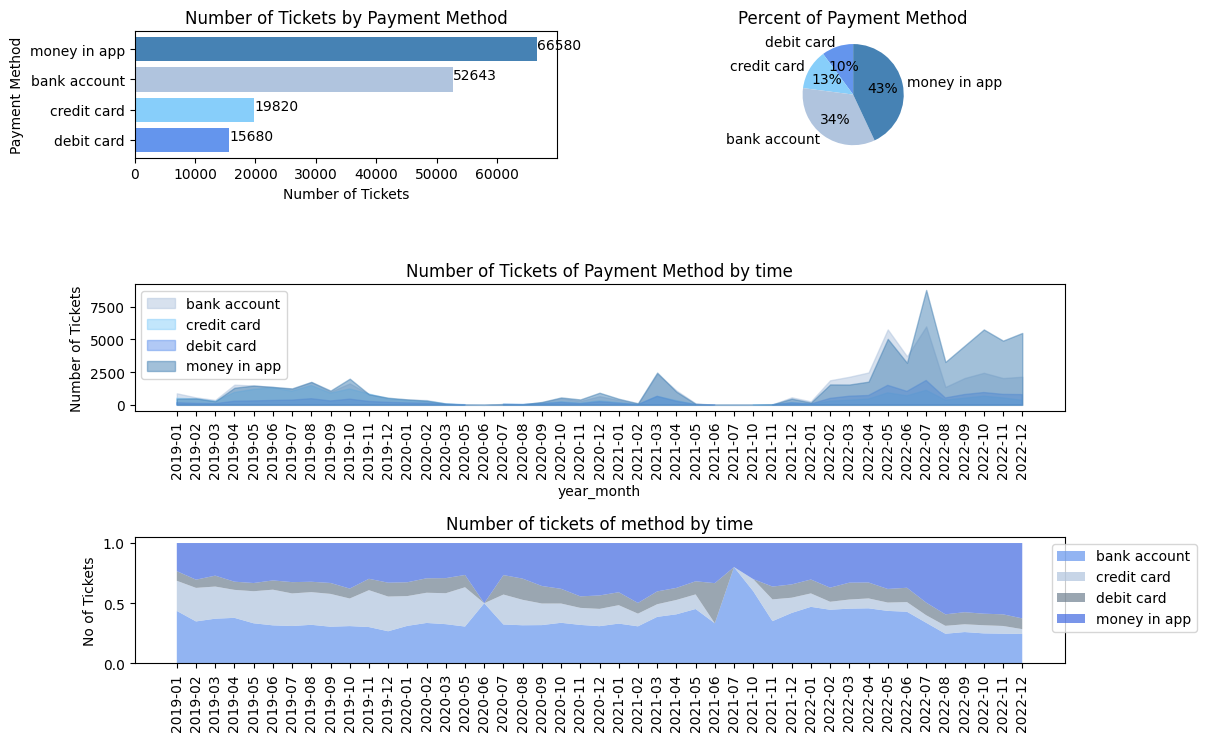

In [80]:
plt.figure(figsize= (12,8))

#Plot 1
axis1=plt.subplot(3,2,1)
plt.barh(df_payment_1['paying_method'],
         df_payment_1['no_of_orders'],
         color=df_payment_1['paying_method'].replace({ 'bank account': 'lightsteelblue',  'credit card': 'lightskyblue', 'debit card': 'cornflowerblue', 'money in app': 'steelblue'})
)

plt.title('Number of Tickets by Payment Method')
plt.ylabel('Payment Method')
plt.xlabel('Number of Tickets')

for index, value in enumerate(df_payment_1['no_of_orders']):
  plt.text(value, index, str(value))

#Plot 2
axis2 = plt.subplot(3,2,2)
plt.pie(df_payment_1['no_of_orders'],
        labels=df_payment_1['paying_method'],
        colors=df_payment_1['paying_method'].replace({ 'bank account': 'lightsteelblue',  'credit card': 'lightskyblue', 'debit card': 'cornflowerblue', 'money in app': 'steelblue'}),
        autopct = '%1.0f%%',
    startangle=90)

plt.title('Percent of Payment Method')

#Plot 3
axis3= plt.subplot(3,1,2)
plt.fill_between(df_payment_2['year_month'],df_payment_2['bank account'],color='lightsteelblue',alpha=0.5, label='bank account')
plt.fill_between(df_payment_2['year_month'],df_payment_2['credit card'],color='lightskyblue',alpha=0.5, label='credit card')
plt.fill_between(df_payment_2['year_month'],df_payment_2['debit card'],color='cornflowerblue',alpha=0.5, label='debit card')
plt.fill_between(df_payment_2['year_month'],df_payment_2['money in app'],color='steelblue',alpha=0.5, label='money in app')

plt.title('Number of Tickets of Payment Method by time')
plt.ylabel('Number of Tickets')
plt.xlabel('year_month')
plt.xticks(rotation=90)
plt.legend()

#Plot 4
axis4=plt.subplot(3,1,3)
plt.stackplot(df_payment_3['year_month'],
              df_payment_3['bank account_pct'],
              df_payment_3['credit card_pct'],
              df_payment_3['debit card_pct'],
              df_payment_3['money in app_pct'],
              labels = ['bank account','credit card',	'debit card',	'money in app'],
              colors=['cornflowerblue','lightsteelblue','slategrey','royalblue'],
              alpha=0.7
)
plt.title('Number of tickets of method by time')
plt.ylabel('No of Tickets')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.xticks(rotation=90)

plt.subplots_adjust(hspace = 1.0, top = 0.9)
plt.show()

### **Promotion**

In [81]:
df_join_all.rename(columns={'campaign_type':'type'},inplace=True)

In [82]:
df_join_all[['campaign_id','type']]

,campaign_id,type
0,83330,direct discount
1,83330,direct discount
2,0,unknown
3,85940,direct discount
4,85940,direct discount
...,...,...
154720,97120,direct discount
154721,0,unknown
154722,97120,direct discount
154723,97150,direct discount


In [83]:
df_join_all['type'].value_counts()

,count
type,
direct discount,79829
unknown,63098
voucher,7619
reward point,4179


Notes: Analyze campaign promotions by comparing revenue from Promotion vs. Non-Promotion groups
- Promotion: Direct discount, voucher, reward points
- Non-Promotion: Unknown

In [84]:
df_join_all['campaign_type'] = df_join_all['type'].apply(lambda x: 'Non-Promotion' if x=='unknown' else 'Promotion')
df_join_all. head(2)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,...,model,platform,age,Month,Hour,Day Name,year_month,Dayofweek,os_version,campaign_type
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,...,"iPhone13,1",mobile,36.073922,7,17,Friday,2022-07,4,ios,Promotion
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,...,browser,website,33.790554,7,20,Friday,2022-07,4,browser,Promotion


In [85]:
df_promotion_1 = df_join_all.groupby(['year_month','campaign_type']).agg(no_of_tickets=('ticket_id','count')).sort_values(by='year_month').reset_index()
df_promotion_1.head(5)


,year_month,campaign_type,no_of_tickets
0,2019-01,Non-Promotion,914
1,2019-01,Promotion,1105
2,2019-02,Non-Promotion,1522
3,2019-02,Promotion,104
4,2019-03,Non-Promotion,968


In [86]:
df_promotion_1['year_month'] = pd.to_datetime(df_promotion_1['year_month'], format='%Y-%m')

In [87]:
df_promotion_2 = df_join_all.groupby('campaign_type').agg(no_of_tickets=('ticket_id','count')).sort_values(by='no_of_tickets').reset_index()
df_promotion_2

,campaign_type,no_of_tickets
0,Non-Promotion,63098
1,Promotion,91627


In [88]:
#Pivot table
df_promotion_3 =  df_promotion_1.pivot_table(index='year_month',columns='campaign_type',values='no_of_tickets').reset_index()
df_promotion_3.head(5)

campaign_type,year_month,Non-Promotion,Promotion
0,2019-01-01,914.0,1105.0
1,2019-02-01,1522.0,104.0
2,2019-03-01,968.0,36.0
3,2019-04-01,2148.0,1921.0
4,2019-05-01,1952.0,2478.0


In [89]:
df_promotion_4 = df_promotion_3.fillna(0)
df_promotion_4['total'] = df_promotion_3.iloc[:,1:].sum(axis=1)

for i in df_promotion_4.columns[1:3]:
  df_promotion_4[i+'_pct']= df_promotion_4[i]/df_promotion_4['total']
df_promotion_4.head(5)

campaign_type,year_month,Non-Promotion,Promotion,total,Non-Promotion_pct,Promotion_pct
0,2019-01-01,914.0,1105.0,2019.0,0.452699,0.547301
1,2019-02-01,1522.0,104.0,1626.0,0.936039,0.063961
2,2019-03-01,968.0,36.0,1004.0,0.964143,0.035857
3,2019-04-01,2148.0,1921.0,4069.0,0.527894,0.472106
4,2019-05-01,1952.0,2478.0,4430.0,0.440632,0.559368


#### **Combined view of 4 charts**

<ipython-input-90-b4f896aaeaf8>:54: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  x_values = pd.date_range(start='2019-01', end='2022-12', freq='M').strftime('%Y-%m').tolist()
<ipython-input-90-b4f896aaeaf8>:70: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  x_values = pd.date_range(start='2019-01', end='2022-12', freq='M').strftime('%Y-%m').tolist()


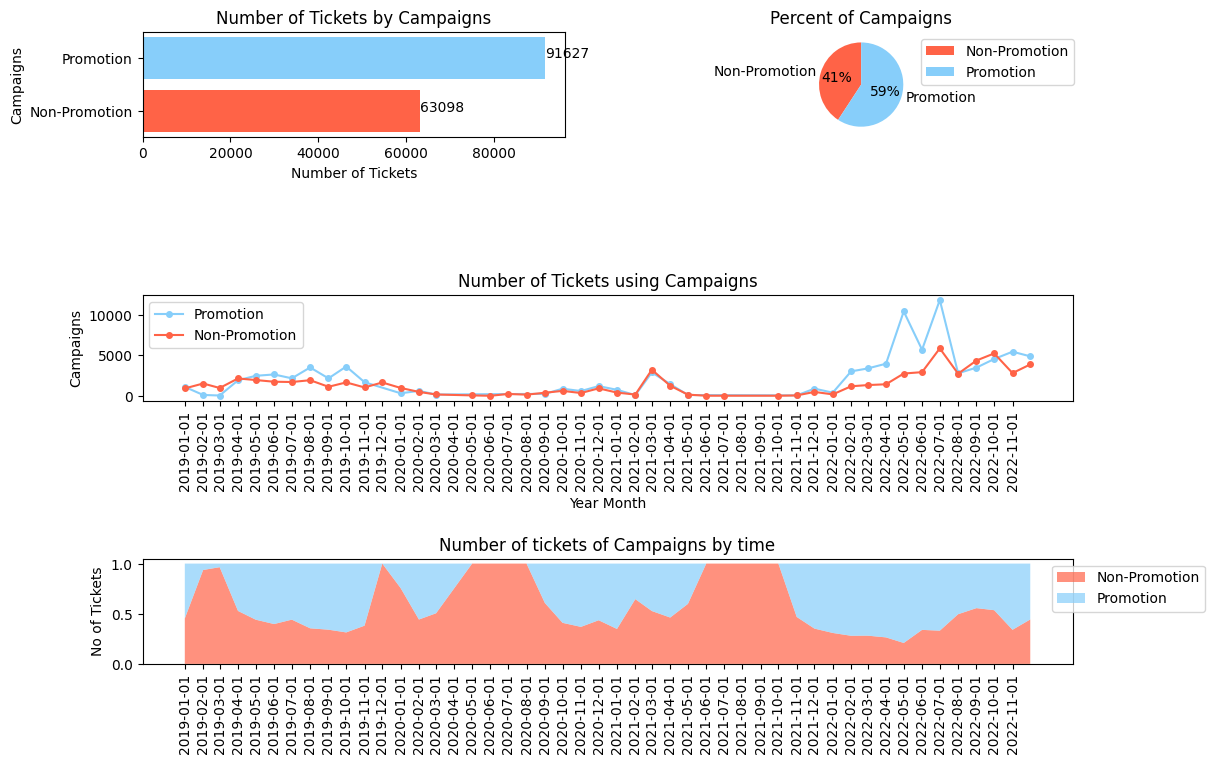

In [90]:
plt.figure(figsize=(12,8))
#Bar Chart
ax1=plt.subplot(3,2,1)
plt.barh(df_promotion_2['campaign_type'],
         df_promotion_2['no_of_tickets'],
         color=df_promotion_2['campaign_type'].replace({'Promotion':'lightskyblue','Non-Promotion':'tomato'}))

plt.title('Number of Tickets by Campaigns')
plt.ylabel('Campaigns')
plt.xlabel('Number of Tickets')


for index, value in enumerate(df_promotion_2['no_of_tickets']):
  plt.text(value, index, str(value))

#Pie chart
ax2=plt.subplot(3,2,2)
plt.pie(df_promotion_2['no_of_tickets'],
        labels=df_promotion_2['campaign_type'],
        autopct='%1.0f%%',
         startangle=90,
        colors=df_promotion_2['campaign_type'].replace({'Promotion':'lightskyblue','Non-Promotion':'tomato'}))

plt.title('Percent of Campaigns')
plt.legend(bbox_to_anchor=(1, 1))

#Line chart
ax3=plt.subplot(3,1,2)

df_pro = df_promotion_1[df_promotion_1['campaign_type']=='Promotion']
df_non_pro = df_promotion_1[df_promotion_1['campaign_type']=='Non-Promotion']

plt.plot(df_pro['year_month'],
         df_pro['no_of_tickets'],
         label = 'Promotion',
         marker = 'o',
         markersize =4,
         color='lightskyblue',
         linewidth=1.5)

plt.plot(df_non_pro['year_month'],
         df_non_pro['no_of_tickets'],
         label = 'Non-Promotion',
         marker = 'o',
         markersize =4,
         color='tomato',
         linewidth=1.5)

plt.title('Number of Tickets using Campaigns')
plt.xlabel('Year Month')
plt.ylabel('Campaigns')
plt.legend()

x_values = pd.date_range(start='2019-01', end='2022-12', freq='M').strftime('%Y-%m').tolist()
plt.xticks(x_values, rotation=90)

#100% stacked area chart
ax4=plt.subplot(3,1,3)
plt.stackplot(df_promotion_4['year_month'],
              df_promotion_4['Non-Promotion_pct'],
              df_promotion_4['Promotion_pct'],
              labels = ['Non-Promotion','Promotion'],
              colors=['tomato','lightskyblue'],
              alpha=0.7
)
plt.title('Number of tickets of Campaigns by time')
plt.ylabel('No of Tickets')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))

x_values = pd.date_range(start='2019-01', end='2022-12', freq='M').strftime('%Y-%m').tolist()
plt.xticks(x_values, rotation=90)

#Show
plt.subplots_adjust(hspace = 1.5, top = 0.9)
plt.show()


### **Which movies they watched ?**

In [91]:
df_movie_1 = df_join_all[df_join_all['status_id']==1].groupby('movie_name').agg(no_of_tickets=('ticket_id','count'),
                                                   total_cus=('customer_id','nunique'), #Vì 1 khách hàng có thể mua nhiều vé
                                                   total_revenue=('final_price','sum')).sort_values(by='no_of_tickets',ascending=False).reset_index()
df_movie_1.head(5)

,movie_name,no_of_tickets,total_cus,total_revenue
0,Doctor Strange In The Multiverse Of Madness,8615,8409,65579.98
1,Minions: The Rise Of Gru,7224,7014,56530.93
2,Avatar: The Way Of Water,5870,5612,59830.95
3,Thor: Love And Thunder,5589,5478,43372.90
4,Peninsula,5499,5365,41208.44


Notes: Due to the large number of movies, the analysis below focuses only on films with ticket sales over 1,000

In [92]:
#List the name of 100 movies
list_movie_name = df_movie_1[df_movie_1['no_of_tickets']>=1000]['movie_name'].unique()
selected_list_movie=list(list_movie_name)
selected_list_movie

['Doctor Strange In The Multiverse Of Madness',
 'Minions: The Rise Of Gru',
 'Avatar: The Way Of Water',
 'Thor: Love And Thunder',
 'Peninsula',
 'Black Panther 2: Wakanda Forever',
 'Black Adam',
 'Avengers: Endgame',
 "Dad I'm Sorry",
 'Love Destiny',
 'You And Trinh',
 'Fast & Furious Presents: Hobbs & Shaw',
 'Emergency Declaration',
 'Jurassic World Dominion',
 'Godzilla Vs. Kong',
 'Detective Conan: The Bride Of Halloween',
 'Joker',
 'Spider-Man: No Way Home',
 'Batman',
 'Blood Moon Party',
 'Fantastic Beasts: Secrets Of Dumbledore',
 'Top Gun: Maverick',
 'Naked Truth',
 "Doraemon: Nobita's Little Star Wars 2021",
 'One Piece Film: Red',
 'Confidential Assignment 2: International',
 'Extremely Easy Job',
 'Morbius',
 'Spider-Man Far From Home',
 'Maleficent',
 'Face Off: 48h',
 'Parasite']

In [93]:
df_movie_2 = df_join_all[(df_join_all['status_id']==1) & df_join_all['movie_name'].isin(selected_list_movie)].groupby(['year_month','movie_name']).agg(no_of_tickets=('ticket_id','count')).reset_index()
df_movie_2.head(4)

,year_month,movie_name,no_of_tickets
0,2019-04,Avengers: Endgame,2081
1,2019-05,Avengers: Endgame,1130
2,2019-06,Avengers: Endgame,8
3,2019-06,Parasite,751


In [94]:
#Pivot Table
df_movie_3 = df_movie_2.pivot_table(index='year_month',columns='movie_name',values='no_of_tickets').reset_index()
df_movie_3.head(5)

movie_name,year_month,Avatar: The Way Of Water,Avengers: Endgame,Batman,Black Adam,Black Panther 2: Wakanda Forever,Blood Moon Party,Confidential Assignment 2: International,Dad I'm Sorry,Detective Conan: The Bride Of Halloween,...,Morbius,Naked Truth,One Piece Film: Red,Parasite,Peninsula,Spider-Man Far From Home,Spider-Man: No Way Home,Thor: Love And Thunder,Top Gun: Maverick,You And Trinh
0,2019-04,NaN,2081.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-05,NaN,1130.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-06,NaN,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,751.0,NaN,28.0,NaN,NaN,NaN,NaN
3,2019-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,286.0,NaN,1125.0,NaN,NaN,NaN,NaN
4,2019-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


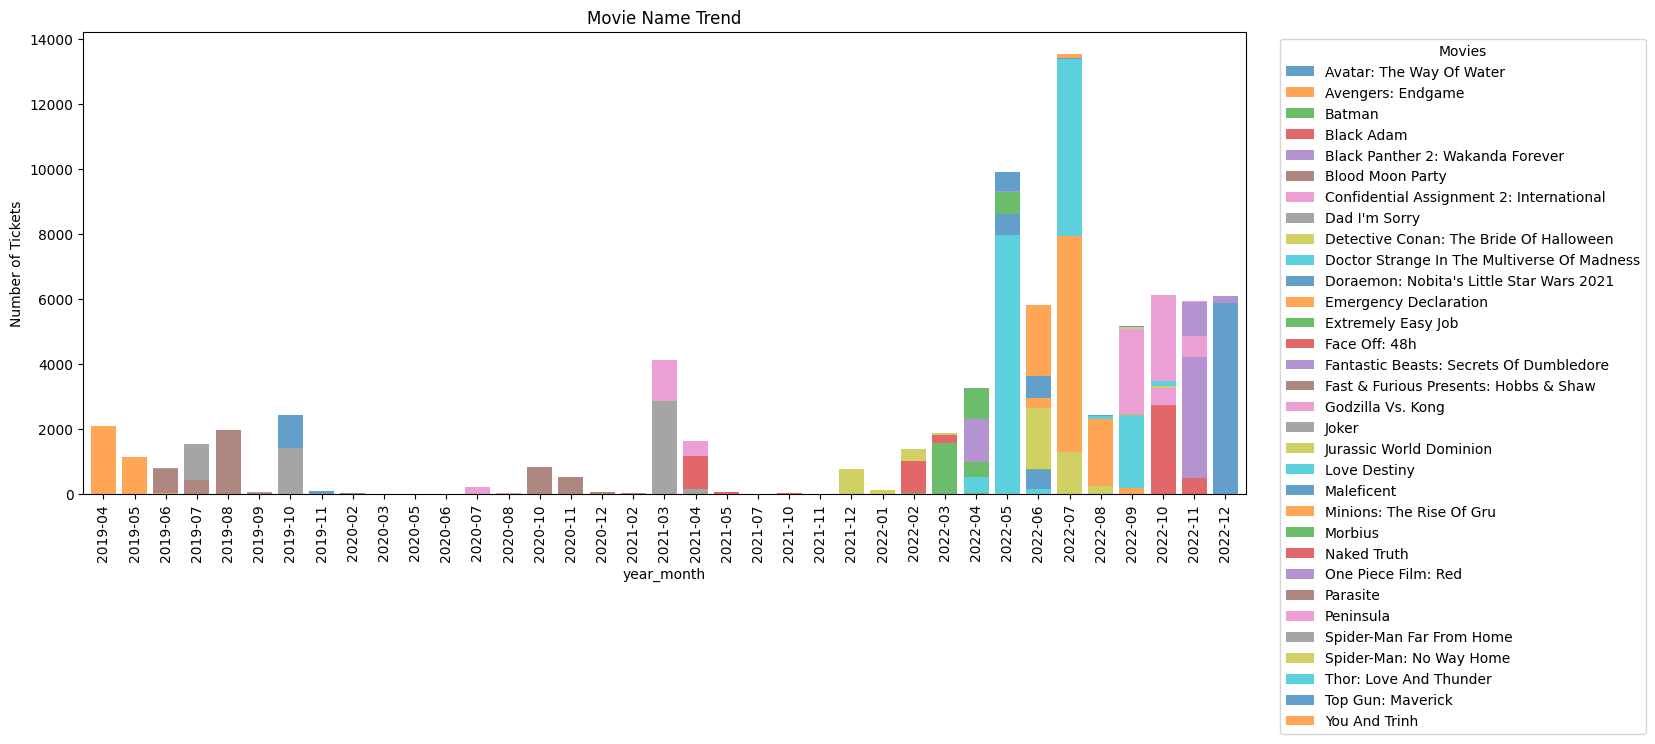

In [95]:
ax = df_movie_3.plot(x='year_month', kind='bar',stacked='True',figsize=(15,6),width=0.8, alpha=0.7)

ax.set_title('Movie Name Trend')
ax.set_ylabel('Number of Tickets')

plt.legend(title='Movies', loc='upper right', bbox_to_anchor=(1.35, 1))

plt.show()

In [96]:
#TOP 5 movies with the highest ticket sales
df_movie_2.sort_values(by='no_of_tickets', ascending=False).head(5)

,year_month,movie_name,no_of_tickets
53,2022-05,Doctor Strange In The Multiverse Of Madness,7973
70,2022-07,Minions: The Rise Of Gru,6648
100,2022-12,Avatar: The Way Of Water,5870
71,2022-07,Thor: Love And Thunder,5471
95,2022-11,Black Panther 2: Wakanda Forever,3742


In [97]:
df_join_all['year'] = pd.to_datetime(df_join_all['time']).dt.year

# Top 2 highest-grossing movies each year
top_movies_each_year = df_join_all.groupby('year').apply(lambda x: x.nlargest(2, 'final_price')).reset_index(drop=True)

top_movies_each_year[['ticket_id','year','year_month','movie_name','final_price']]

<ipython-input-97-21a2e979d786>:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_movies_each_year = df_join_all.groupby('year').apply(lambda x: x.nlargest(2, 'final_price')).reset_index(drop=True)


,ticket_id,year,year_month,movie_name,final_price
0,0bb289281a7a62b86253937a2415d9d1,2019,2019-04,Avengers: Endgame,74.23
1,57b14cb0c347a6ac585aa0b894fb70ae,2019,2019-09,Anna,74.23
2,b3489199654e3c1fecd26695e7336eae,2020,2020-10,Pawn,64.05
3,90ca82309b0277d93b24786c6909cd19,2020,2020-01,The Royal Bride,57.65
4,c08c38cc9e6f994a199544ad2d51b69a,2021,2021-03,Godzilla Vs. Kong,74.89
5,bc676b7af7f4892a3b83c6cdf0278b09,2021,2021-03,Godzilla Vs. Kong,74.23
6,0acaccd3ca2f31e9e0725c3798ca3557,2022,2022-11,Black Panther 2: Wakanda Forever,92.91
7,f6a2c75a522ae79adad206df5c215e3d,2022,2022-07,Thor: Love And Thunder,86.60


## **3.4. Customer value dimension**

> **Objective: Analyze the value metrics a customer brings**
>> + **Frequency:** count, day, month
>> + **Monetary:** total_money, total_discount
>> + **Success rate** = number_success/total_success
>> + **Discount_rate** = sum_discount/sum_money

In [98]:
#Run the dataset across all columns
pd.set_option('display.max_colwidth',None)
pd.set_option('display.max_columns',None)
df_join_all.head(4)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,usergender,dob,description,error_group,type,model,platform,age,Month,Hour,Day Name,year_month,Dayofweek,os_version,campaign_type,year
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,Male,1989-02-25,Order successful,unknown,direct discount,"iPhone13,1",mobile,36.073922,7,17,Friday,2022-07,4,ios,Promotion,2022
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,Male,1991-06-09,Order successful,unknown,direct discount,browser,website,33.790554,7,20,Friday,2022-07,4,browser,Promotion,2022
2,1fdbeb7eceba8a27d9d985b5b70c219a,100596,money in app,56.0,69cf9244654949047f006e441fa7a8a7,10.31,2.31,8.00,2022-07-30 11:16:55.483,1,0,Thor: Love And Thunder,Male,1989-05-18,Order successful,unknown,unknown,unknown,mobile,35.849418,7,11,Saturday,2022-07,5,unknown,Non-Promotion,2022
3,7715c9955866bd296b98543412839abd,100852,bank account,119.0,879ed11af9d6d2b5cda4d299590735a7,27.75,1.03,26.72,2022-07-04 22:33:07.458,1,85940,Thor: Love And Thunder,Male,1997-08-31,Order successful,unknown,direct discount,devicemodel,mobile,27.561944,7,22,Monday,2022-07,0,android & others,Promotion,2022


In [99]:
#Add the col 'Date' df_join_all
df_join_all['Date']=df_join_all['time'].dt.strftime('%Y-%m-%d')

In [100]:
# create Table 1 for Successful Customers (status_id=1)
# add a function to calculate successful transactions
def cal_n_promotion(x):
  return(x=='Promotion').sum()

df_success_metric = df_join_all[df_join_all['status_id']==1].groupby('customer_id').agg(n_success=('ticket_id','count'),
                                                  no_of_months=('year_month','nunique'),
                                                  total_money=('original_price','sum'),
                                                  total_discount=('discount_value','sum'),
                                                  total_promotion=('campaign_type',cal_n_promotion),
                                                  no_of_days=('Date','nunique')).reset_index()
df_success_metric.head(5)

,customer_id,n_success,no_of_months,total_money,total_discount,total_promotion,no_of_days
0,100001,1,1,7.42,2.06,1,1
1,100003,6,6,60.95,2.56,1,6
2,100004,1,1,32.25,0.00,0,1
3,100005,1,1,9.49,2.06,1,1
4,100006,1,1,12.37,0.00,0,1


In [101]:
calc_null_rate(df_success_metric)

,null_count,null_rate
customer_id,0,0.0
n_success,0,0.0
no_of_months,0,0.0
total_money,0,0.0
total_discount,0,0.0
total_promotion,0,0.0
no_of_days,0,0.0


In [102]:
#Create table 2 for failed payment customers

def cal_no_success(x):
  return(x!=1).sum()

df_failed_metric = df_join_all.groupby('customer_id').agg(no_of_tickets=('ticket_id','count'),
                                                           n_failed=('status_id',cal_no_success)).reset_index()

df_failed_metric.head(5)

,customer_id,no_of_tickets,n_failed
0,100001,1,0
1,100003,6,0
2,100004,1,0
3,100005,1,0
4,100006,1,0


In [103]:
#Mergetable 1 and table 2
df_value_1 = pd.merge(df_failed_metric, df_success_metric,how='left',on='customer_id').fillna(0)
df_value_1.head(5)

,customer_id,no_of_tickets,n_failed,n_success,no_of_months,total_money,total_discount,total_promotion,no_of_days
0,100001,1,0,1.0,1.0,7.42,2.06,1.0,1.0
1,100003,6,0,6.0,6.0,60.95,2.56,1.0,6.0
2,100004,1,0,1.0,1.0,32.25,0.00,0.0,1.0
3,100005,1,0,1.0,1.0,9.49,2.06,1.0,1.0
4,100006,1,0,1.0,1.0,12.37,0.00,0.0,1.0


In [104]:
#Cal other metrics
df_value_1['success_rate']=df_value_1['n_success']/df_value_1['no_of_tickets']
df_value_1['promotion_rate']=df_value_1['total_promotion']/df_value_1['n_success']
df_value_1['discount_rate']=df_value_1['total_discount']/df_value_1['total_money']
df_value_1.head(5)


,customer_id,no_of_tickets,n_failed,n_success,no_of_months,total_money,total_discount,total_promotion,no_of_days,success_rate,promotion_rate,discount_rate
0,100001,1,0,1.0,1.0,7.42,2.06,1.0,1.0,1.0,1.000000,0.277628
1,100003,6,0,6.0,6.0,60.95,2.56,1.0,6.0,1.0,0.166667,0.042002
2,100004,1,0,1.0,1.0,32.25,0.00,0.0,1.0,1.0,0.000000,0.000000
3,100005,1,0,1.0,1.0,9.49,2.06,1.0,1.0,1.0,1.000000,0.217071
4,100006,1,0,1.0,1.0,12.37,0.00,0.0,1.0,1.0,0.000000,0.000000


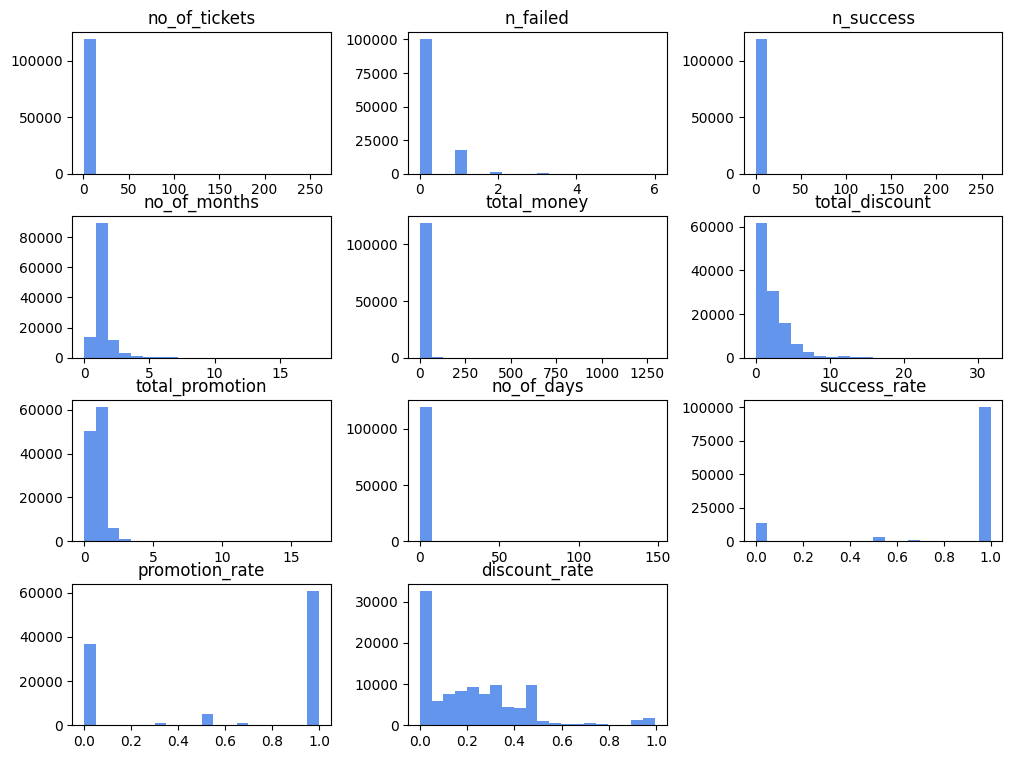

In [105]:
df_value_1.iloc[:,1:].hist(figsize=(12,9),grid=False,color='cornflowerblue', bins=20)
plt.show()

**Notes:**
- Most customers buy only 1-2 tickets, but a few buy a lot → Check these users
- Success Rate: ~10% of transactions have a Success Rate = 0% → Possible issue?
- Promotion Rate: 6,000+ customers only used promotions (rate = 100%)
- 6,000 customers used promotions only once—any link to the 100% promotion rate group?

### **Frequency & anomaly behavior**

In [106]:
df_value_1['customers_dis'] = df_value_1['n_success'].apply(lambda x:'more than 10' if x>=10
                                                                 else str(x))


In [107]:
# How many customers correspond to each ticket quantity?
df_value_2 = df_value_1.groupby('customers_dis').agg(no_of_customers=('customer_id','count')).reset_index()
df_value_2

,customers_dis,no_of_customers
0,0.0,13701
1,1.0,87921
2,2.0,12902
3,3.0,3145
4,4.0,1017
5,5.0,380
6,6.0,168
7,7.0,92
8,8.0,47
9,9.0,30


Notes: Vì số lượng khách mua số lượng vé lớn cỡ từ 1-3 người => Gộp luôn vào nhóm (more than 10: mua nhiều hơn 10 vé)

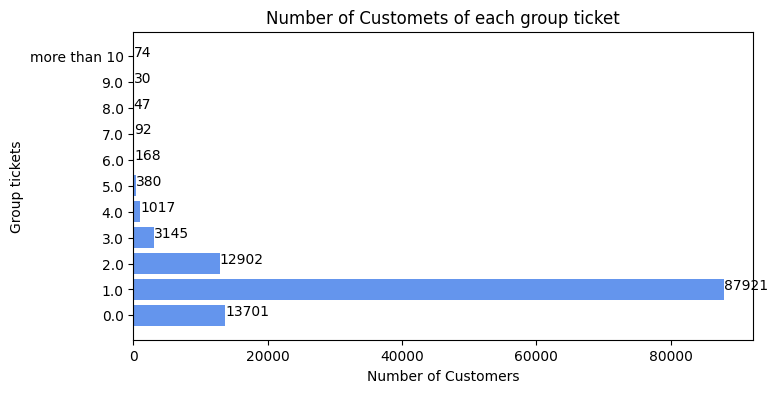

In [108]:
plt.figure(figsize=(8,4))

plt.barh(df_value_2['customers_dis'],
         df_value_2['no_of_customers'],
         color='cornflowerblue')

plt.title('Number of Customets of each group ticket')
plt.ylabel('Group tickets')
plt.xlabel('Number of Customers')

for index, value in enumerate(df_value_2['no_of_customers']):
  plt.text(value, index, str(value))


In [109]:
df_value_1.count()

,0
customer_id,119477
no_of_tickets,119477
n_failed,119477
n_success,119477
no_of_months,119477
total_money,119477
total_discount,119477
total_promotion,119477
no_of_days,119477
success_rate,119477


Notes: Out of 119,477 customers:
- 87,921 customers bought only 1 ticket (73.58%)
- 13.4% purchased 2-3 tickets
- A small group bought a high number of tickets → needs further analysis:
> - Bulk purchase at once → Possible hoarding ?
> - Spread over time → Normal behavior

In [110]:
df_value_3 = df_value_1.groupby('n_success').agg(no_of_customers=('customer_id','count')).sort_values(by='n_success',ascending=False).reset_index()

Notes:
- 1 customer purchased 260 tickets (highest)
- 4 customers bought 100-110 tickets

In [111]:
df_value_4 = list(df_value_1[df_value_1['n_success']>30]['customer_id'].unique())

In [112]:
df_value_5 = df_join_all[(df_join_all['status_id']==1) & df_join_all['customer_id'].isin(df_value_4)].groupby(['year_month','customer_id']).agg(no_of_tickets=('ticket_id','count')).reset_index()


In [113]:
# Pivot table
df_value_6 = df_value_5.pivot_table(index='year_month',columns='customer_id',values='no_of_tickets').reset_index()

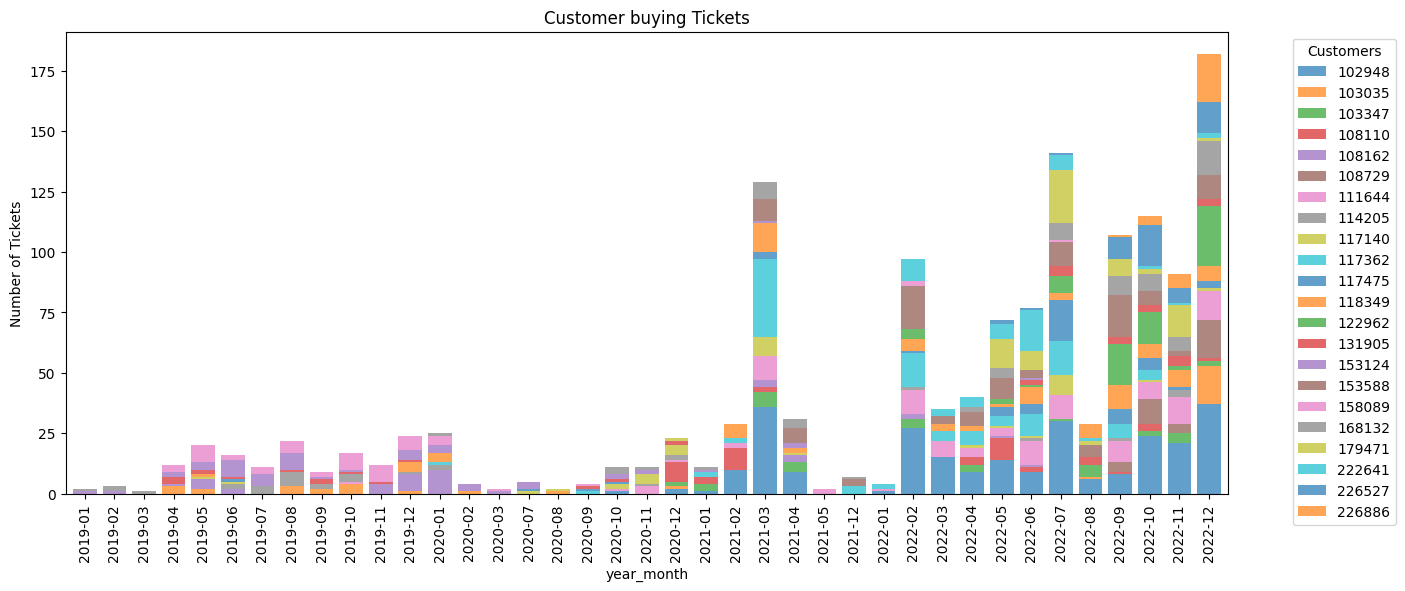

In [114]:
ax = df_value_6.plot(x='year_month', kind='bar',stacked='True',figsize=(15,6),width=0.8, alpha=0.7)

ax.set_title('Customer buying Tickets')
ax.set_ylabel('Number of Tickets')

plt.legend(title='Customers', loc='upper right', bbox_to_anchor=(1.15, 1))

plt.show()

Notes:
- Customers who bought ≥30 tickets had distributed purchases → No signs of ticket hoarding or resale
- No abnormalities detected

### **Promotion's Campaigns**

In [115]:
df_value_1['promotion_dis'] = df_value_1['total_promotion'].apply(lambda x:'more than 10' if x>=10 else str(x))


In [116]:
df_protype_2 = df_value_1.groupby('promotion_dis').agg(no_of_customers=('customer_id','count')).reset_index()


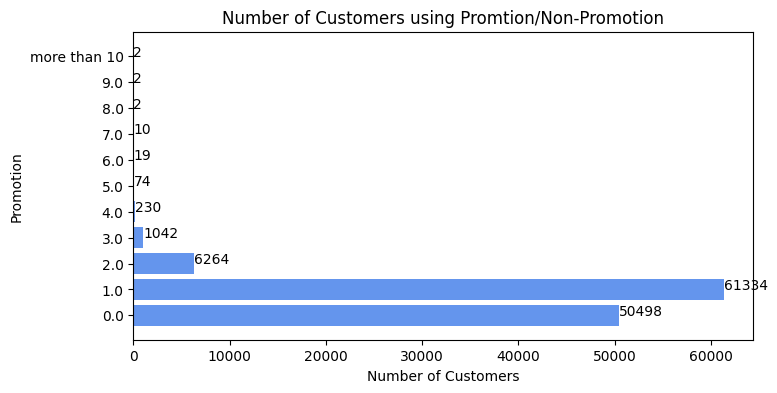

In [117]:
plt.figure(figsize=(8,4))

plt.barh(df_protype_2['promotion_dis'],
         df_protype_2['no_of_customers'],
         color='cornflowerblue')

plt.title('Number of Customers using Promtion/Non-Promotion')
plt.ylabel('Promotion')
plt.xlabel('Number of Customers')

for index, value in enumerate(df_protype_2['no_of_customers']):
  plt.text(value, index, str(value))

In [118]:
df_value_1['customer_id'].count()

np.int64(119477)

In [119]:
#The percentage of customers who never participated in any promotion is:
50498/119477

0.4226587544046134

In [120]:
#The percentage of customers who participated in at least one promotion is:
(119477-50498)/119477

0.5773412455953866

In [121]:
#The percentage of customers who participated in a promotion only once is:
61334/(119477-50498)

0.8891691674277679

Notes:
- ~42% of customers did not participate in any promotions
- ~58% joined at least one promotion
- Among them, 89% used a promotion only once
- Two possible reasons:
> - Customers only purchased once and never returned
> - Promotions were limited to one-time use per customer (targeting new users) → Need to verify with the Product or Marketing team

**Check and analyze the types of promotions customers used**

In [122]:
df_protype_0 = df_join_all[df_join_all['status_id']==1].groupby('type').agg(total=('ticket_id','count')).sort_values(by='total',ascending=False).reset_index()
df_protype_0

,type,total
0,direct discount,68449
1,unknown,55156
2,voucher,6924
3,reward point,3150


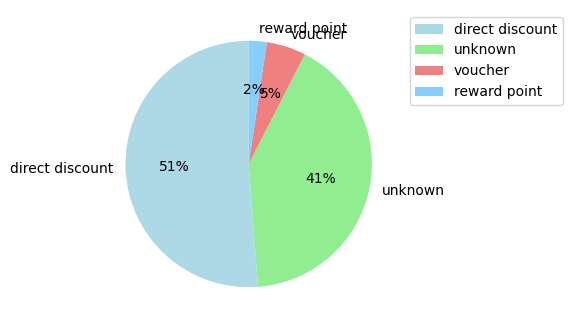

In [123]:
plt.figure(figsize=(8, 4))

plt.pie(df_protype_0['total'],
        labels=df_protype_0['type'],
        autopct='%1.0f%%',
        startangle=90,
        colors=['lightblue', 'lightgreen', 'lightcoral', 'lightskyblue']
)

plt.legend(bbox_to_anchor=(1, 1))
plt.show()


**Calculate the detailed promotion type ratio for each customer group**

In [124]:
df_typepro_3 = df_join_all[(df_join_all['campaign_type']=='Promotion') & df_join_all['status_id']==1].groupby('customer_id').agg(no_of_promotions=('ticket_id','count')).reset_index()


In [125]:
df_typepro_1 = df_join_all[(df_join_all['campaign_type']=='Promotion') & df_join_all['status_id']==1].pivot_table(index='customer_id', columns='type',aggfunc='count',values='ticket_id').reset_index()
df_typepro_1 = df_typepro_1.fillna(0)
df_typepro_1.head(10)


type,customer_id,direct discount,reward point,voucher
0,100001,0.0,0.0,1.0
1,100003,1.0,0.0,0.0
2,100005,0.0,0.0,1.0
3,100007,1.0,0.0,0.0
4,100009,7.0,0.0,0.0
5,100010,1.0,0.0,0.0
6,100012,1.0,0.0,0.0
7,100014,2.0,0.0,0.0
8,100015,0.0,0.0,2.0
9,100018,1.0,0.0,0.0


In [126]:
df_typepro_4 = pd.merge(df_typepro_3,df_typepro_1, how='inner', on='customer_id')
df_typepro_4.head(10)

,customer_id,no_of_promotions,direct discount,reward point,voucher
0,100001,1,0.0,0.0,1.0
1,100003,1,1.0,0.0,0.0
2,100005,1,0.0,0.0,1.0
3,100007,1,1.0,0.0,0.0
4,100009,7,7.0,0.0,0.0
5,100010,1,1.0,0.0,0.0
6,100012,1,1.0,0.0,0.0
7,100014,2,2.0,0.0,0.0
8,100015,2,0.0,0.0,2.0
9,100018,1,1.0,0.0,0.0


In [127]:
df_typepro_4 = df_typepro_4.drop_duplicates(subset=['customer_id'])

In [128]:
df_typepro_5 = df_typepro_4.groupby('no_of_promotions').agg(no_customers=('customer_id','nunique'),
                                                            no_direct_discount=('direct discount','sum'),
                                                            no_reward_point=('reward point','sum'),
                                                            no_voucher=('voucher','sum')).reset_index()
df_typepro_5.head(12)

,no_of_promotions,no_customers,no_direct_discount,no_reward_point,no_voucher
0,1,66802,57826.0,3321.0,5655.0
1,2,7889,14151.0,411.0,1216.0
2,3,1437,3885.0,95.0,331.0
3,4,326,1185.0,16.0,103.0
4,5,106,479.0,6.0,45.0
5,6,26,147.0,0.0,9.0
6,7,10,57.0,0.0,13.0
7,8,6,40.0,2.0,6.0
8,9,2,12.0,0.0,6.0
9,10,2,19.0,0.0,1.0


In [129]:
#Add the col 'Total'
df_typepro_5['total']=df_typepro_5.iloc[:,2:].sum(axis=1)
df_typepro_5

,no_of_promotions,no_customers,no_direct_discount,no_reward_point,no_voucher,total
0,1,66802,57826.0,3321.0,5655.0,66802.0
1,2,7889,14151.0,411.0,1216.0,15778.0
2,3,1437,3885.0,95.0,331.0,4311.0
3,4,326,1185.0,16.0,103.0,1304.0
4,5,106,479.0,6.0,45.0,530.0
5,6,26,147.0,0.0,9.0,156.0
6,7,10,57.0,0.0,13.0,70.0
7,8,6,40.0,2.0,6.0,48.0
8,9,2,12.0,0.0,6.0,18.0
9,10,2,19.0,0.0,1.0,20.0


In [130]:
for i in df_typepro_5.columns[2:5]:
  df_typepro_5[i+'_pct']= df_typepro_5[i]/df_typepro_5['total']

In [131]:
df_typepro_5.head(2)

,no_of_promotions,no_customers,no_direct_discount,no_reward_point,no_voucher,total,no_direct_discount_pct,no_reward_point_pct,no_voucher_pct
0,1,66802,57826.0,3321.0,5655.0,66802.0,0.865633,0.049714,0.084653
1,2,7889,14151.0,411.0,1216.0,15778.0,0.896882,0.026049,0.077069


**Create a heatmap for the promotion programs**:

In [132]:
format_dict = {'total':'{:.0f}','no_voucher_pct':'{:.0%}','no_direct_discount_pct':'{:.0%}','no_reward_point_pct':'{:.0%}'}

In [133]:
(
    df_typepro_5
    .drop(columns= ['no_direct_discount','no_reward_point','no_voucher'])
    .style
    .format(format_dict)
    .background_gradient(subset=['no_voucher_pct', 'no_reward_point_pct', 'no_direct_discount_pct'], cmap='PuBu')
    .background_gradient(subset=['total'], cmap='YlGn')
)


,no_of_promotions,no_customers,total,no_direct_discount_pct,no_reward_point_pct,no_voucher_pct
0,1,66802,66802,87%,5%,8%
1,2,7889,15778,90%,3%,8%
2,3,1437,4311,90%,2%,8%
3,4,326,1304,91%,1%,8%
4,5,106,530,90%,1%,8%
5,6,26,156,94%,0%,6%
6,7,10,70,81%,0%,19%
7,8,6,48,83%,4%,12%
8,9,2,18,67%,0%,33%
9,10,2,20,95%,0%,5%


**Notes:**
- ~90% of customers participate in Direct Discount campaigns
- Evaluate customer retention → Do they return? → Measure marketing effectiveness
> If customers use promotions but don’t return, marketing may not be effective, meaning they only join for the one-time discount

## **3.5 Customer Retention - Cohort Analysis**

> + Evaluate customer retention rate
> + Identify key factors affecting retention
>> Analyze Customer Conversion timing based on: First paymnet; First purchase; First app installation

In [134]:
#Import library
from operator import attrgetter
import matplotlib.colors as mcolors
import seaborn as sns

Notes: Xem lại data ở trên, thì năm 2020 và 2021 bị thiếu dữ liệu nên sẽ phân tích và so sánh theo 2 năm 2019 và 2022 thôi

In [135]:
df_selected_time = df_join_all[(df_join_all['time']>='2022-01-01') & (df_join_all['status_id']==1)]
df_selected_time['first_month'] = df_selected_time.groupby('customer_id')['time'].transform('min').dt.to_period('M')
df_selected_time['current_month'] = df_selected_time['time'].dt.to_period('M')
df_selected_time['subsequent_month']=(df_selected_time['current_month']-df_selected_time['first_month']).apply(attrgetter('n'))

<ipython-input-135-563ba3bc7971>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected_time['first_month'] = df_selected_time.groupby('customer_id')['time'].transform('min').dt.to_period('M')
<ipython-input-135-563ba3bc7971>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected_time['current_month'] = df_selected_time['time'].dt.to_period('M')
<ipython-input-135-563ba3bc7971>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_index

In [136]:
df_cohort = df_selected_time.groupby(['first_month','current_month','subsequent_month']).agg(no_of_customers=('customer_id','nunique')).reset_index()
df_cohort_pivot = df_cohort.pivot_table(index='first_month',columns='subsequent_month',values='no_of_customers')
cohort_size = df_cohort_pivot.iloc[:,0]
retention_matrix = df_cohort_pivot.iloc[:,0:].divide(cohort_size, axis=0)

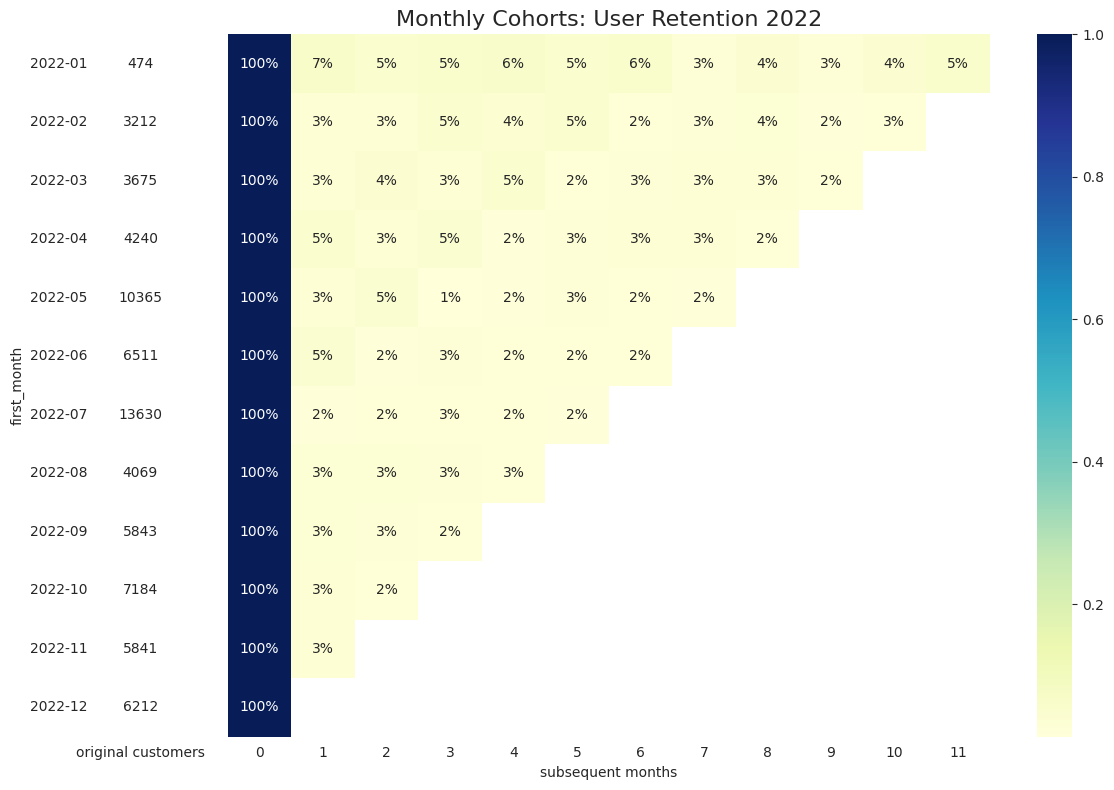

In [137]:
with sns.axes_style("white"):
    fig, ax = plt.subplots(1, 2, figsize=(12, 8), sharey=True, gridspec_kw={'width_ratios': [1, 11]})

    # retention matrix
    sns.heatmap(retention_matrix,
                mask=retention_matrix.isnull(),
                annot=True,
                fmt='.0%',
                cmap='YlGnBu',
                ax=ax[1])
    ax[1].set_title('Monthly Cohorts: User Retention 2022', fontsize=16)
    ax[1].set(xlabel='subsequent months',
              ylabel='')

    # cohort size
    cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: 'original customers'})
    white_cmap = mcolors.ListedColormap(['white'])
    sns.heatmap(cohort_size_df,
                annot=True,
                cbar=False,
                fmt='g',
                cmap=white_cmap,
                alpha=0.5,
                ax=ax[0])

    fig.tight_layout()

**NOTES:**  
- Retention Rate in 2019 and 2022 remained unchanged as the market was still recovering
- Despite 60-65% of traffic from promotions in 2022, retention remained low

Notes: Analyze whether the Retention Rate differs significantly between Promotion and Non-Promotion groups in 2022

In [138]:
df_year19_cus = df_join_all[(df_join_all['time']>='2022-01-01') & (df_join_all['status_id']==1)].groupby('campaign_type').agg(no_of_customer=('customer_id','nunique')).reset_index()

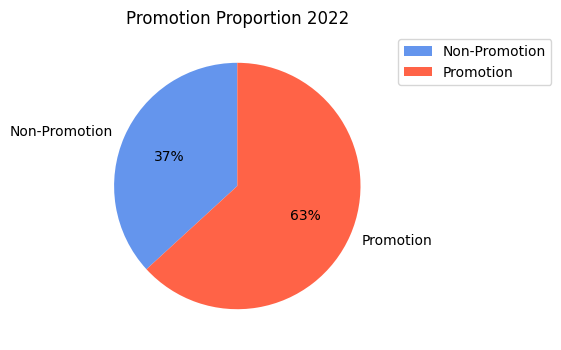

In [139]:
plt.figure(figsize=(8,4))

plt.pie(df_year19_cus['no_of_customer'],
        labels=df_year19_cus['campaign_type'],
        autopct='%1.0f%%',
        startangle=90,
        colors=('cornflowerblue','tomato')
)

plt.title('Promotion Proportion 2022')
plt.legend()
plt.legend(bbox_to_anchor=(1, 1))

In [140]:
df_year19_ticket = df_join_all[(df_join_all['time']>='2022-01-01') & (df_join_all['status_id']==1)].groupby('campaign_type').agg(no_of_tickets=('ticket_id','nunique')).reset_index()


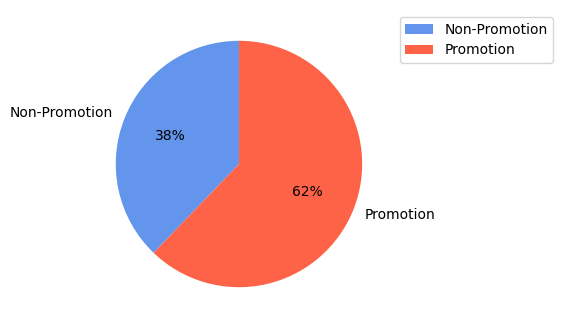

In [141]:
plt.figure(figsize=(8,4))

plt.pie(df_year19_ticket['no_of_tickets'],
        labels=df_year19_ticket['campaign_type'],
        autopct='%1.0f%%',
        startangle=90,
        colors=('cornflowerblue','tomato')
)
plt.legend()
plt.legend(bbox_to_anchor=(1, 1))

**Notes:**

Notes: Differentiate customers based on their first order: Promotion or Organic (Non-Promotion)
- Assign order numbers by customer_id
- If the first order (stt = 1) is a Promotion, classify as Promotion (First_Order)
- To check retention, find customer_id with stt = 2 in the Promotion group (i.e., they returned for a second purchase after using a promotion)

In [142]:
df_data_check = df_join_all[(df_join_all['time']>'2022-01-01') & (df_join_all['status_id']==1)][['customer_id','ticket_id','time','campaign_type']].sort_values(by=['customer_id','time'])

In [143]:
# Assign a sequence number to each customer’s orders
df_data_check['row_number']=df_data_check.groupby('customer_id').cumcount() + 1
df_data_check.head(5)

,customer_id,ticket_id,time,campaign_type,row_number
66484,100003,34c4764b4afa000af4c33a525f20eace,2022-05-22 12:52:12.105,Non-Promotion,1
10001,100004,1c4aa39842bfc83dbb5856c25a33d9cb,2022-12-20 06:26:21.373,Non-Promotion,1
108794,100007,5565ba5e22475c7cce298a2bea470428,2022-03-21 17:57:18.460,Promotion,1
0,100009,4f5200dcdcf2396b8d50ff84bf423f32,2022-07-08 17:46:36.145,Promotion,1
5585,100009,0724203b5146b0ebae6e3678ed7eccde,2022-12-24 09:32:45.477,Promotion,2


In [144]:
# Count the number of customers whose first order belongs to the Promotion group
df_data_check[(df_data_check['campaign_type']=='Promotion') & df_data_check['row_number']==1]['customer_id'].nunique()

46397

In [145]:
46397/47505

0.9766761393537522

Notes:
- Compared to the Pie chart; 47,505 customers participated in Promotion in 2022, with 46397/47505 (~97%) being first-time participants

> How many of them returned? → Calculate Retention Rate

In [146]:
df_first_promo_list = df_data_check[(df_data_check['campaign_type']=='Promotion') & df_data_check['row_number']==1]['customer_id']
df_first_promo_list.drop_duplicates(inplace=True)

#Merge the two tables to create a dataset containing only customers who used Promotion for the first time
df_first_promo_check = pd.merge(df_data_check,df_first_promo_list, how='inner', on='customer_id')
df_first_promo_check. head(5)

<ipython-input-146-0bbc5b129b5f>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_first_promo_list.drop_duplicates(inplace=True)


,customer_id,ticket_id,time,campaign_type,row_number
0,100007,5565ba5e22475c7cce298a2bea470428,2022-03-21 17:57:18.460,Promotion,1
1,100009,4f5200dcdcf2396b8d50ff84bf423f32,2022-07-08 17:46:36.145,Promotion,1
2,100009,0724203b5146b0ebae6e3678ed7eccde,2022-12-24 09:32:45.477,Promotion,2
3,100020,af02fc96a6703af7d93162d9f8c61dba,2022-05-28 19:09:37.936,Promotion,1
4,100023,5ed44ff62214268ffcb14d4ea78b04d8,2022-05-16 08:45:42.397,Promotion,1


In [147]:
(
    df_first_promo_check[df_first_promo_check['row_number']==2]['customer_id'].nunique()
    /
    df_first_promo_check['customer_id'].nunique()
)

0.134793197836067

Notes: 13.4% of customers returned after their first Promotion purchase
> What about the Organic group?

In [148]:
df_data_check[(df_data_check['campaign_type']=='Non-Promotion') & df_data_check['row_number']==1]['customer_id'].nunique()

25565

In [149]:
list_first_non_promo = df_data_check[(df_data_check['campaign_type']=='Non-Promotion') & df_data_check['row_number']==1]['customer_id']
list_first_non_promo.drop_duplicates(inplace=True)

df_first_non_promo_check = pd.merge(df_data_check,list_first_non_promo, how='inner', on='customer_id')

(
    df_first_non_promo_check[df_first_non_promo_check['row_number']==2]['customer_id'].nunique()
    /
    df_first_non_promo_check['customer_id'].nunique()
)


<ipython-input-149-6f6615760a99>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  list_first_non_promo.drop_duplicates(inplace=True)


0.13905730490905535

Notes: The first-time Organic customer group has a 13.9% retention rate


## **3.6 Payment success rate**

In [150]:
def cal_success(x):
  return(x==1).sum()

df_sr = df_join_all.groupby('year_month').agg(n_ords=('ticket_id','count'),
                                                   n_success=('status_id',cal_success)).reset_index()
df_sr.head(5)

,year_month,n_ords,n_success
0,2019-01,2019,1359
1,2019-02,1626,1427
2,2019-03,1004,866
3,2019-04,4069,3190
4,2019-05,4430,3617


In [151]:
#Add col: success_rate (=n_success/n_order)

df_sr['success_rate']=(df_sr['n_success']/df_sr['n_ords'])*100
df_sr.head(5)

,year_month,n_ords,n_success,success_rate
0,2019-01,2019,1359,67.310550
1,2019-02,1626,1427,87.761378
2,2019-03,1004,866,86.254980
3,2019-04,4069,3190,78.397641
4,2019-05,4430,3617,81.647856


Text(0.5, 1.0, 'Payment success rate by months')

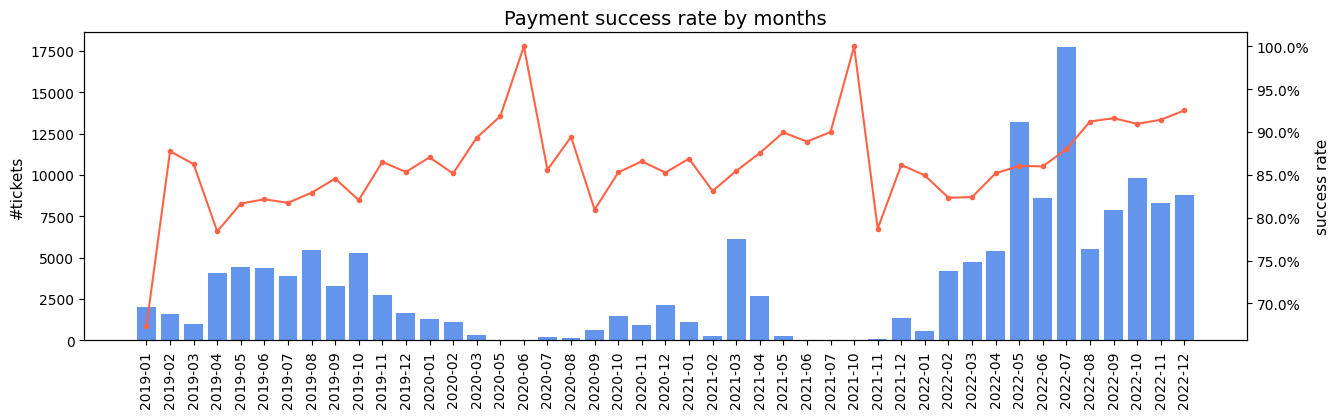

In [152]:
# a combined chart with a bar chart (number of orders) and a line chart (order success rate)

from matplotlib.ticker import PercentFormatter

fig, ax1 = plt.subplots(figsize=(15,4))

ax1.bar(df_sr['year_month'], df_sr['n_ords'], color="cornflowerblue")
plt.ylabel('#tickets', fontsize=11)
plt.xticks(rotation='vertical')

ax2 = ax1.twinx()
ax2.plot(df_sr['year_month'], df_sr['success_rate'], color="tomato", marker="o", ms=3)
ax2.yaxis.set_major_formatter(PercentFormatter())

plt.ylabel('success rate', fontsize=11)
plt.title('Payment success rate by months', fontsize=14)


Notes:
- SR fluctuates between 80-90%; 100% indicates missing data
- High success, but errors persist → Check error groups


In [153]:
def cal_success(x):
  return(x==1).sum()

df_sr_payment = df_join_all[df_join_all['paying_method']!='other'].groupby('paying_method').agg(n_ords=('ticket_id','count'),
                                                   n_success=('status_id',cal_success)).reset_index()

df_sr_payment['success_rate']=(df_sr_payment['n_success']/df_sr_payment['n_ords'])*100
df_sr_payment.sort_values(by='success_rate',ascending=False).head(5)

,paying_method,n_ords,n_success,success_rate
3,money in app,66580,64817,97.352058
0,bank account,52643,42057,79.890964
1,credit card,19820,15408,77.739657
2,debit card,15680,11395,72.672194


#### **Error Trend**

In [154]:
df_error_group = df_join_all[df_join_all['status_id']!=1].groupby(['year_month','error_group']).agg(n_ords=('ticket_id','count')).reset_index()
df_error_group.head(5)

,year_month,error_group,n_ords
0,2019-01,customer,291
1,2019-01,external,369
2,2019-02,customer,66
3,2019-02,external,133
4,2019-03,customer,44


In [155]:
df_error_group['error_group'].unique()

array(['customer', 'external', 'internal'], dtype=object)

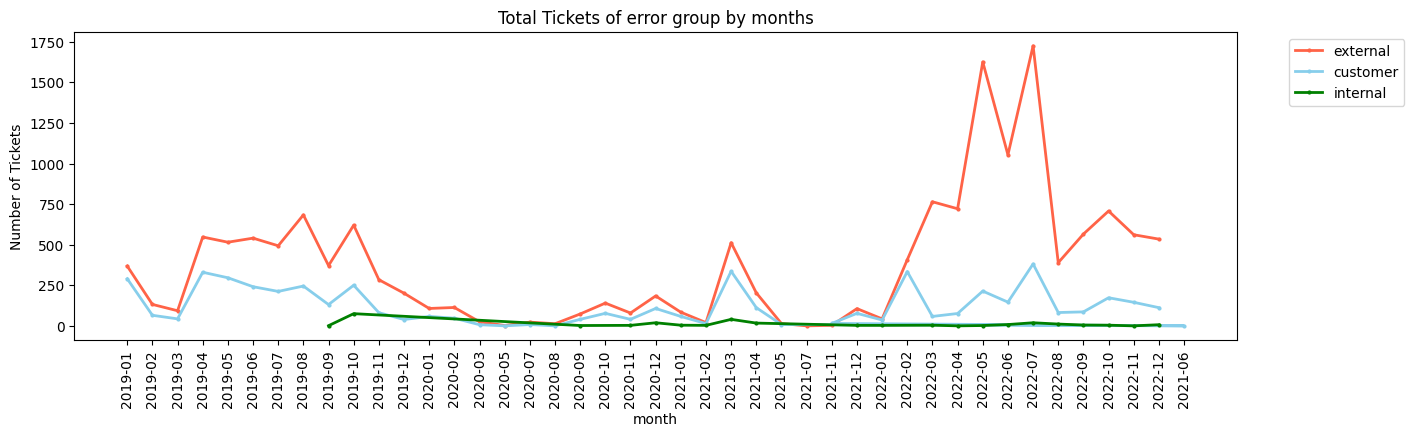

In [156]:
error_color_pairs = [('external','tomato'),('customer','skyblue'),('internal','green')]

plt.figure(figsize=(15,4))
for error, color in error_color_pairs:
  df_err_line = df_error_group[df_error_group['error_group']==error]
  plt.plot(df_err_line['year_month'],
           df_err_line['n_ords'],
           label=error,
           marker='o',
           color=color,
           linewidth=2,
           markersize=2)

plt.title('Total Tickets of error group by months')
plt.xlabel('month')
plt.ylabel('Number of Tickets')
plt.legend(loc='upper right',bbox_to_anchor=(1.15,1))
plt.xticks(rotation=90)
plt.show()

Notes:
- Customer errors spread evenly
- Few internal errors
- External errors surged in 2022

In [157]:
df_error = df_join_all[df_join_all['status_id']!=1].groupby(['year_month','description']).agg(n_ords=('ticket_id','count')).sort_values(by='year_month').reset_index()
df_error.head(5)

,year_month,description,n_ords
0,2019-01,Insufficient funds in customer account. Please add more funds and try the transaction again.,217
1,2019-01,No response from your bank,228
2,2019-01,Password locked due to multiple incorrect attempts. Choose Forgot Password to unlock.,56
3,2019-01,Payment failed from bank,141
4,2019-01,Payment overdue,18


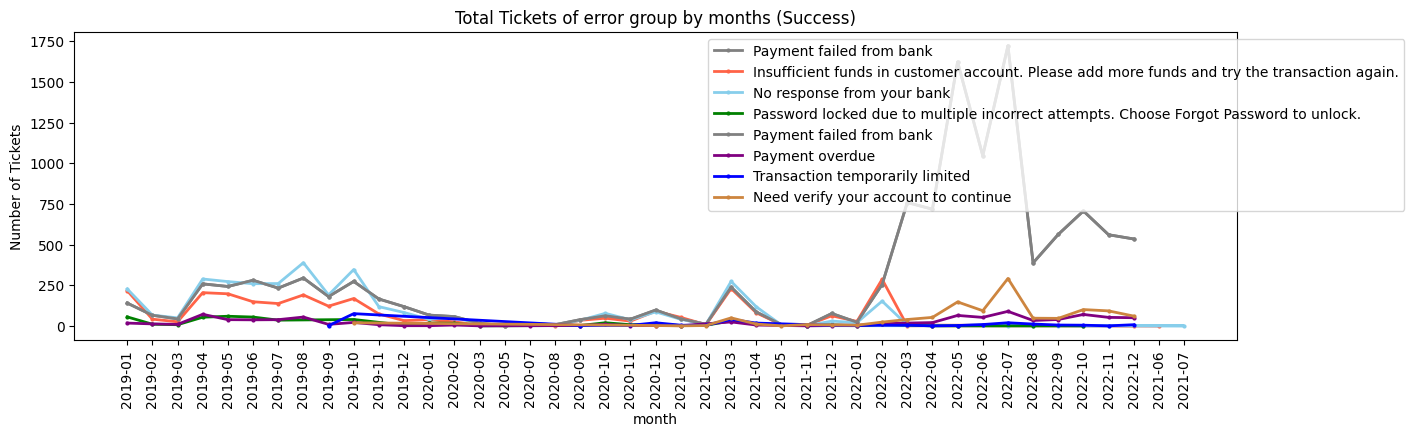

In [158]:
error_color_pairs = [('Payment failed from bank','gray'),
 ('Insufficient funds in customer account. Please add more funds and try the transaction again.','tomato'),
  ('No response from your bank','skyblue'),
   ('Password locked due to multiple incorrect attempts. Choose Forgot Password to unlock.','green'),
    ('Payment failed from bank','gray'),
     ('Payment overdue','purple'),
      ('Transaction temporarily limited','blue'),
       ('Need verify your account to continue','peru')]

plt.figure(figsize=(15,4))
for error, color in error_color_pairs:
  df_err_line = df_error[df_error['description']==error]
  plt.plot(df_err_line['year_month'],
           df_err_line['n_ords'],
           label=error,
           marker='o',
           color=color,
           linewidth=2,
           markersize=2)

plt.title('Total Tickets of error group by months (Success)')
plt.xlabel('month')
plt.ylabel('Number of Tickets')
plt.legend(loc='upper right',bbox_to_anchor=(1.15,1))
plt.xticks(rotation=90)
plt.show()

Notes: Bank errors spiked in 2022 (Payment failed from bank)

#### **Why & How Success_rate = 0%**

In [159]:
list_sr_0 = list(df_value_1[df_value_1['success_rate']<0.1]['customer_id'].unique())

In [160]:
def cal_n_promotion(x):
  return(x=='Promotion').sum()

df_sr_0_metric = (
    df_join_all[df_join_all['customer_id'].isin(list_sr_0)]
    .groupby('customer_id')
    .agg(n_orders = ('ticket_id','count'),
         s_money=('original_price','sum'),
         s_discount=('discount_value','sum'),
         n_promotions=('campaign_type',cal_n_promotion)).reset_index()
)

In [161]:
df_sr_0_metric['promotion_rate'] = df_sr_0_metric['n_promotions']/df_sr_0_metric['n_orders']
df_sr_0_metric['discount_rate'] = df_sr_0_metric['s_discount']/df_sr_0_metric['s_money']

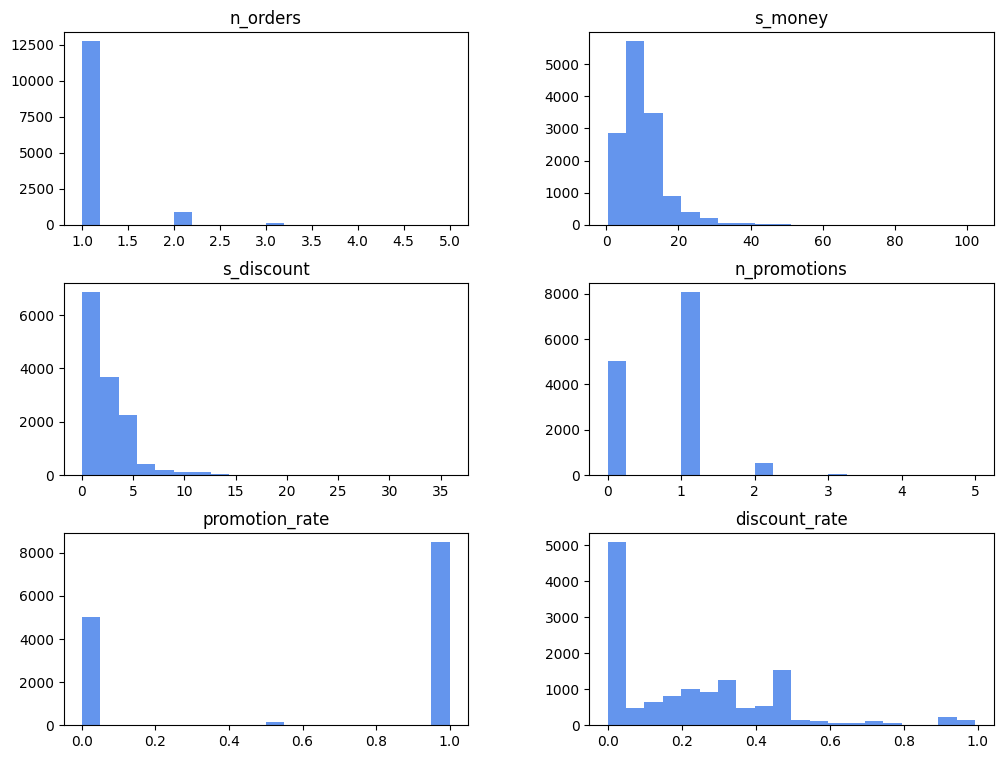

In [162]:
df_sr_0_metric.iloc[:,1:].hist(figsize=(12,9),grid=False,color='cornflowerblue', bins=20)
plt.show()

Notes: What error caused them to fail once and stop without retrying?

In [163]:
df_error_0 = (
    df_join_all[(df_join_all['status_id']!=1) & (df_join_all['customer_id'].isin(list_sr_0))]
    .groupby(['year_month','description'])
    .agg(n_ords=('ticket_id','count'))
    .sort_values(by ='year_month',ascending=True)
    .reset_index()

  )

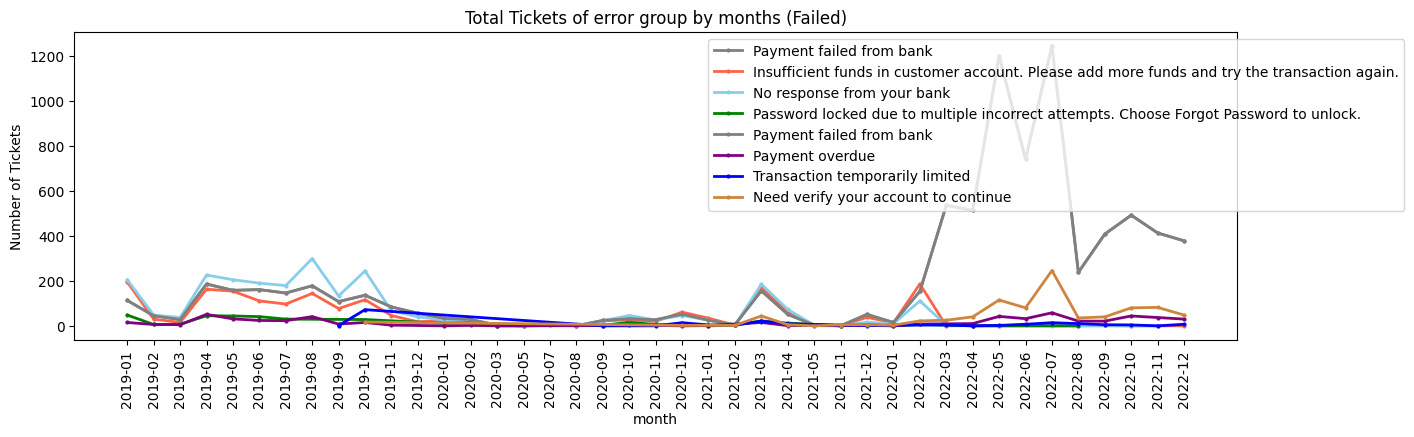

In [164]:
error_color_pairs = [('Payment failed from bank','gray'),
 ('Insufficient funds in customer account. Please add more funds and try the transaction again.','tomato'),
  ('No response from your bank','skyblue'),
   ('Password locked due to multiple incorrect attempts. Choose Forgot Password to unlock.','green'),
    ('Payment failed from bank','gray'),
     ('Payment overdue','purple'),
      ('Transaction temporarily limited','blue'),
       ('Need verify your account to continue','peru')]

plt.figure(figsize=(15,4))
for error, color in error_color_pairs:
  df_err_line = df_error_0[df_error_0['description']==error]
  plt.plot(df_err_line['year_month'],
           df_err_line['n_ords'],
           label=error,
           marker='o',
           color=color,
           linewidth=2,
           markersize=2)

plt.title('Total Tickets of error group by months (Failed)')
plt.xlabel('month')
plt.ylabel('Number of Tickets')
plt.legend(loc='upper right',bbox_to_anchor=(1.15,1))
plt.xticks(rotation=90)
plt.show()

Notes:
-  Errors in this group match overall customer errors
- Reasons for failure and no retry:
> - Bank issues beyond their control
> - Account verification failure (fraud suspicion or upgrade rejection)

# **4. Insights and Recommendations**

**You can click this link to have a quick view of Insights & Recommendation**

**Thank you for taking the time to read this analysis. I appreciate your interest and welcome any feedback**
> **Nguyễn Thùy Linh**
>**ngthuylinh3003@gmail.com**
